# Notebook 02 : Exploratory Data Analysis

**Project:** Thematic Evolution of French Electoral Manifestos (1973-1993)  
**Course:** Machine Learning for NLP - ENSAE Paris, 2025-2026  
**Author:** Gabriel Orsatti

---

This notebook performs three key tasks:

1. **Text preprocessing** : cleaning, tokenization, and stopword removal. (Ref: Lecon 1 - Vector Representation for NLP)
2. **Feature engineering** : party family classification and BERT-based profession mapping. (Ref: Lecon 7 - Transformers)
3. **Exploratory visualization** : corpus structure, socio-demographic profiles, and temporal trends

The input is `df_complet.pkl` produced in Notebook 01. The output is `df_explore.pkl`, enriched with cleaned text, tokens, party families, and PCS profession categories.

---

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
from collections import Counter
import re
import string
import os
import json
import urllib.request

df = pd.read_pickle("../data/df_complet.pkl")
print(f"DataFrame loaded: {len(df):,} rows × {len(df.columns)} columns")

DataFrame loaded: 21,697 rows × 47 columns


---

## 2. Initial Descriptive Statistics

Before any transformation, let us understand the raw structure of the corpus: how many documents per year, what parties are represented, and what the demographic breakdown looks like.

### 2.1 Corpus composition

In [2]:
print("=== Documents per year ===")
print(df['year'].value_counts().sort_index())

print("\n=== Documents per election type ===")
print(df['election_type'].value_counts())

print("\n=== Top 15 parties (titulaire-soutien) ===")
print(df['titulaire-soutien'].value_counts().head(15))

=== Documents per year ===
year
1973    3921
1978    5030
1981    3182
1988    3628
1993    5936
Name: count, dtype: int64

=== Documents per election type ===
election_type
legislatives    21697
Name: count, dtype: int64

=== Top 15 parties (titulaire-soutien) ===
titulaire-soutien
non mentionné                                                          4040
Parti communiste français                                              2474
Parti socialiste                                                       1735
Front national                                                         1366
Lutte ouvrière                                                         1023
Rassemblement pour la République;Union pour la démocratie française     764
Rassemblement pour la République                                        637
Union pour la démocratie française;Rassemblement pour la République     455
Parti socialiste unifié                                                 441
Nouveaux écologistes du rassembl

Note that `non mentionné` (not specified) accounts for ~4,000 entries (~18.6% of the corpus). These documents lack any party affiliation metadata, making them uninformative for cross-party analyses. We will **exclude them from all party-based comparisons** below, while retaining them for corpus-wide text statistics.

### 2.2 Demographic overview

In [3]:
print("=== Gender distribution ===")
print(df['titulaire-sexe'].value_counts())

print("\n=== Age brackets ===")
print(df['titulaire-age-tranche'].value_counts())

=== Gender distribution ===
titulaire-sexe
homme            18171
femme             2160
non déterminé      836
Name: count, dtype: int64

=== Age brackets ===
titulaire-age-tranche
non mentionné         13232
entre 40 et 49 ans     2742
entre 30 et 39 ans     2589
entre 50 et 59 ans     1266
entre 20 et 29 ans     1058
entre 60 et 69 ans      264
entre 70 et 79 ans       16
Name: count, dtype: int64


The gender imbalance is striking: over 82% of candidates are male. The age data is largely missing, which limits age-based analyses to a subset of the corpus.

---

## 3. Text Preprocessing

The first step of any text-based pipeline is **preprocessing**: lowercasing, punctuation removal, and stopword filtering. These operations reduce the dimensionality of the vocabulary and focus on content-bearing words. In practice, the course emphasizes that normalization and stop word removal have very limited impact on downstream performance; the truly critical parameter is the **vocabulary size** (typically ~10k dimensions). (Ref: Lecon 1 - Vector Representation for NLP)

### 3.1 Text cleaning

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("=== Raw text sample ===")
print(df['text'].iloc[0][:300])
print("\n=== Cleaned text sample ===")
print(df['text_clean'].iloc[0][:300])

=== Raw text sample ===
Sciences Po / fonds CEVIPOF
RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRATERNITÉ - DÉPARTEMENT DE L'AIN
3e CIRCONSCRIPTION
ÉLECTIONS LÉGISLATIVES DU 4 MARS 1973
MOUVEMENT DES RADICAUX DE GAUCHE (Union de la Gauche Socialiste et Démocrate)
Candidat : Louis LAMARCHE
56 ans Négociant en Produits Agric

=== Cleaned text sample ===
sciences po fonds cevipof république française liberté égalité fraternité département de lain e circonscription élections législatives du mars mouvement des radicaux de gauche union de la gauche socialiste et démocrate candidat louis lamarche ans négociant en produits agricoles conseiller général ma


The cleaning pipeline performs four operations: lowercasing, newline removal, punctuation stripping, and digit removal. This is a standard Bag-of-Words preprocessing approach. Note that we do **not** apply lemmatization at this stage, we will experiment with it in the topic modeling notebook.

### 3.2 Tokenization and stopword removal

In [5]:
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'été', 'non', 'oui', 'puis', 'ici', 'là',
    'ya', 'ça', 'cela', 'ceci', 'on', 'ny', 'na', 'ni',
    # OCR watermark artifacts ("Sciences Po / fonds CEVIPOF" header)
    'sciences', 'fonds', 'cevipof',
    # Domain-specific electoral terms (near-universal in corpus)
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'cest', 'dune', 'électeur'
}

def tokenize(text):
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_FR and len(t) > 2]

df['tokens'] = df['text_clean'].apply(tokenize)
df['n_tokens'] = df['tokens'].apply(len)

print(f"Mean tokens per document: {df['n_tokens'].mean():.0f}")
print(f"Token sample: {df['tokens'].iloc[0][:20]}")

Mean tokens per document: 347
Token sample: ['liberté', 'égalité', 'fraternité', 'lain', 'mouvement', 'radicaux', 'gauche', 'union', 'gauche', 'socialiste', 'démocrate', 'louis', 'lamarche', 'ans', 'négociant', 'produits', 'agricoles', 'conseiller', 'général', 'maire']


Our stopword list includes three layers of filtering:

1. **Standard French function words** (`le`, `de`, `pour`, etc.) that carry no semantic content.
2. **Domain-specific electoral terms** (`circonscription`, `candidat`, `elections`, etc.) that appear in virtually every manifesto and carry no discriminative information for topic modeling. As noted in the course, terms with very high document frequency have near-zero IDF weight, confirming their negligible contribution. (Ref: Lecon 1 - Vector Representation for NLP)
3. **OCR watermark artifacts** (`sciences`, `fonds`, `cevipof`) originating from the "Sciences Po / fonds CEVIPOF" header that the OCR engine systematically transcribes from every scanned document. Without removal, these artifacts dominate frequency rankings and pollute downstream analyses.

### 3.3 Most frequent words

In [6]:
def get_top_words(df_subset, n=20):
    all_tokens = [token for tokens in df_subset['tokens'] for token in tokens]
    return Counter(all_tokens).most_common(n)

print("=== Top 20 global words ===")
for word, count in get_top_words(df):
    print(f"  {word}: {count:,}")

=== Top 20 global words ===


  politique: 42,184
  ans: 40,154
  gauche: 39,799
  parti: 34,240
  travailleurs: 29,573
  français: 29,396
  contre: 27,202
  vie: 26,953
  majorité: 25,545
  faut: 25,265
  pays: 24,739
  candidats: 23,386
  droite: 22,903
  travail: 21,781
  suppléant: 21,387
  socialiste: 20,348
  nationale: 20,021
  député: 19,667
  programme: 19,042
  communiste: 19,030


---

## 4. Feature Engineering

### 4.1 Party family classification

The raw `titulaire-soutien` field contains hundreds of unique party labels (including coalitions like `RPR;UDF`). Rather than mapping to individual parties, we classify each document into one of **six political families** that structure the French political landscape during 1973–1993:

| Family | Typical parties |
|--------|----------------|
| **Gauche radicale** | PCF, LO, LCR, PSU, various Trotskyist/Maoist groups |
| **Gauche modérée** | PS, MRG, Parti socialiste unifié (post-1981 alliances) |
| **Centre** | UDF, CDS, Parti radical, Mouvement réformateur |
| **Écologistes** | Verts, Génération écologie, Nouveaux écologistes, MEI |
| **Droite** | RPR, URP, Gaullistes, CNI |
| **Extrême droite** | Front national, FN dissidences |

Documents labeled `non mentionné` (~18.6% of the corpus) are **excluded from party-based analyses**: since we cannot determine their political affiliation, including them would distort cross-party comparisons. They remain in the full dataset for text-level analyses (vocabulary, text length).

In [7]:
def classify_family(soutien):
    """
    Classifie le libellé brut du soutien en l'une des 6 familles politiques.
    Version optimisée pour réduire drastiquement la catégorie 'Autre'.
    """
    if not isinstance(soutien, str):
        return None
    
    # Nettoyage de base : on met en minuscules et on enlève les espaces inutiles
    s = soutien.lower().strip()
    if 'non mentionné' in s or s == '':
        return None

    # On gère le cas multi-partis (séparés par ;)
    parts = [p.strip() for p in s.split(';')]
    
    for p in parts:
        # On découpe le libellé en mots isolés pour chercher les sigles exacts
        # (Cela évite que "profession" soit matché avec le sigle "pr")
        words = p.split()

        # 1. Extrême droite
        mots_ed = ['front national', 'rassemblement national', 'forces nouvelles', 'extrême droite', 'extreme droite', 'nationaliste']
        sigles_ed = ['fn', 'mnr', 'pfn']
        if any(x in p for x in mots_ed) or any(sigle in words for sigle in sigles_ed):
            return 'Extrême droite'

        # 2. Gauche radicale (En conservant votre choix d'y inclure le PCF)
        mots_gr = ['communiste', 'lutte ouvrière', 'ligue', 'socialiste unifié', 'travailleur', 'trotsky', 'trotski', 'maoïste', 'marxiste', 'révolution', 'extrême gauche', 'extreme gauche', 'autogestion']
        sigles_gr = ['pcf', 'lo', 'lcr', 'psu', 'pci', 'pt']
        if any(x in p for x in mots_gr) or any(sigle in words for sigle in sigles_gr):
            return 'Gauche radicale'

        # 3. Gauche modérée
        mots_gm = ['parti socialiste', 'socialiste', 'radicaux de gauche', 'mouvement des citoyens', 'chevènement', 'majorité présidentielle', 'union de la gauche', 'convention des institutions', 'gauche alternative', 'démocrate']
        sigles_gm = ['ps', 'mrg', 'prg', 'mdc']
        if any(x in p for x in mots_gm) or any(sigle in words for sigle in sigles_gm):
            return 'Gauche modérée'

        # 4. Écologistes
        mots_eco = ['vert', 'écologi', 'ecologi', 'nature', 'environnement', 'animaux', 'génération écologie']
        sigles_eco = ['mei', 'aei', 'ge']
        if any(x in p for x in mots_eco) or any(sigle in words for sigle in sigles_eco):
            return 'Écologistes'

        # 5. Centre
        mots_cen = ['démocratie française', 'centre', 'centriste', 'démocrates sociaux', 'radical valoisien', 'parti radical', 'réformateur', 'progrès et démocratie moderne']
        sigles_cen = ['udf', 'cds', 'pdm', 'cdp']
        if any(x in p for x in mots_cen) or any(sigle in words for sigle in sigles_cen):
            return 'Centre'

        # 6. Droite
        mots_dr = ['rassemblement pour la république', 'gaulliste', 'nouvelle république', 'républicains de progrès', 'divers droite', 'indépendant', 'parti républicain', 'union des démocrates']
        sigles_dr = ['rpr', 'udr', 'unr', 'cnip', 'cni', 'pr', 'ri']
        if any(x in p for x in mots_dr) or any(sigle in words for sigle in sigles_dr):
            return 'Droite'

    return 'Autre'

df['famille_politique'] = df['titulaire-soutien'].apply(classify_family)

# Summary statistics
stats_family = df['famille_politique'].value_counts(dropna=False)
stats_family_pct = (stats_family / len(df) * 100).round(1)

print("=== Political family distribution ===\n")
for fam, count in stats_family.items():
    label = fam if fam else "Non mentionné (excluded)"
    print(f"  {label:35s} {count:5d}  ({stats_family_pct[fam]:5.1f}%)")

n_excluded = df['famille_politique'].isna().sum()
n_autre = (df['famille_politique'] == 'Autre').sum()
n_classified = len(df) - n_excluded - n_autre
print(f"\n→ {n_classified:,} documents classified into 6 families ({n_classified/len(df)*100:.1f}%)")
print(f"→ {n_excluded:,} 'non mentionné' excluded from party analyses ({n_excluded/len(df)*100:.1f}%)")
print(f"→ {n_autre:,} minor/unclassifiable parties in 'Autre' ({n_autre/len(df)*100:.1f}%)")

# Working subset for party-based analyses
df_party = df[df['famille_politique'].notna() & (df['famille_politique'] != 'Autre')].copy()
FAMILIES = ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']
print(f"\n→ Working subset for party analyses: {len(df_party):,} documents")

=== Political family distribution ===

  Gauche radicale                      4967  ( 22.9%)
  Non mentionné (excluded)             4570  ( 21.1%)
  Gauche modérée                       3370  ( 15.5%)
  Droite                               3059  ( 14.1%)
  Centre                               1817  (  8.4%)
  Extrême droite                       1590  (  7.3%)
  Écologistes                          1350  (  6.2%)
  Autre                                 974  (  4.5%)

→ 16,153 documents classified into 6 families (74.4%)
→ 4,570 'non mentionné' excluded from party analyses (21.1%)
→ 974 minor/unclassifiable parties in 'Autre' (4.5%)

→ Working subset for party analyses: 16,153 documents


### 4.2 Profession classification with BERT (zero-shot)

The `titulaire-profession` field contains over 2,000 unique free-text entries (e.g., *"professeur agrege de lettres"*, *"directeur commercial adjoint"*). A keyword-based approach would miss many variants. Instead, we leverage a **zero-shot classification** model based on XLM-RoBERTa, which can assign each profession to one of 15 PCS-inspired categories without any task-specific training data. This approach exploits the contextual embeddings and the Natural Language Inference (NLI) paradigm: for each profession string, the model evaluates the hypothesis *"This person works as a [category]"* and returns the most probable category. (Ref: Lecon 7 - Transformers)

**Performance note:** Classification is run only once. Results are cached to `profession_pcs_mapping.json` for subsequent runs.

In [8]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [10]:
CACHE_PATH = "../data/profession_pcs_mapping.json"

PCS_CATEGORIES = [
    "Agriculteur, exploitant agricole",
    "Artisan, commerçant, chef d'entreprise",
    "Profession médicale ou paramédicale",
    "Profession juridique",
    "Enseignant, chercheur, universitaire",
    "Cadre supérieur, ingénieur",
    "Cadre moyen, technicien",
    "Employé, fonctionnaire",
    "Ouvrier",
    "Journaliste, artiste, communication",
    "Militaire, policier, sécurité",
    "Profession commerciale, vente",
    "Étudiant, retraité, sans emploi",
    "Permanent politique ou syndical",
    "Profession religieuse",
]

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    # Check if new professions from 1973/1978 are missing from the cache
    unique_professions_all = df['titulaire-profession'].dropna().unique()
    missing = [p for p in unique_professions_all
               if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']
               and p not in results]
    if missing:
        print(f"Cache loaded but {len(missing)} new professions not yet classified → will classify them.")
        needs_classification = True
    else:
        needs_classification = False
        print(f"Cache loaded: {len(results)} professions mapped from {CACHE_PATH} (all professions covered ✓)")
else:
    needs_classification = True

if needs_classification:
    print("Launching BERT classification for new/uncached professions...")
    print("(Results will be merged into the cache for future use)\n")

    try:
        import sentencepiece
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "sentencepiece", "protobuf", "--quiet"])
        print("sentencepiece installed - RESTART THE KERNEL then re-run this cell.")
        raise SystemExit("Kernel restart required after sentencepiece installation.")

    import torch
    from transformers import XLMRobertaTokenizer, AutoModelForSequenceClassification, pipeline
    from tqdm import tqdm

    tokenizer = XLMRobertaTokenizer.from_pretrained("joeddav/xlm-roberta-large-xnli")
    model = AutoModelForSequenceClassification.from_pretrained("joeddav/xlm-roberta-large-xnli")

    classifier = pipeline(
        "zero-shot-classification",
        model=model,
        tokenizer=tokenizer,
        device=-1
    )

    unique_professions = df['titulaire-profession'].dropna().unique()
    # If a partial cache exists, only classify what's missing
    if not os.path.exists(CACHE_PATH):
        results = {}
        to_classify = [p for p in unique_professions
                       if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']]
    else:
        to_classify = missing  # only the new professions from 1973/1978
    print(f"Unique professions to classify: {len(to_classify)}")
    for i in tqdm(range(0, len(to_classify), 16), desc="Classification"):
        batch = to_classify[i:i+16]
        for profession in batch:
            try:
                result = classifier(
                    profession,
                    candidate_labels=PCS_CATEGORIES,
                    hypothesis_template="Cette personne travaille comme {}."
                )
                results[profession] = result['labels'][0]
            except Exception as e:
                results[profession] = 'Autre'

    for p in unique_professions:
        if p not in results:
            results[p] = 'Non renseigné'

    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\nCache updated and saved to {CACHE_PATH}")

# Apply mapping
df['profession_pcs'] = df['titulaire-profession'].map(results)
df['profession_pcs'] = df['profession_pcs'].fillna('Non renseigné')

print("\n=== PCS category distribution ===\n")
pcs_counts = df['profession_pcs'].value_counts()
for cat, count in pcs_counts.items():
    pct = count / len(df) * 100
    print(f"  {cat:50s} {count:5d}  ({pct:5.1f}%)")

Cache loaded: 3397 professions mapped from ../data/profession_pcs_mapping.json (all professions covered ✓)

=== PCS category distribution ===

  Non renseigné                                      10011  ( 46.1%)
  Enseignant, chercheur, universitaire                2716  ( 12.5%)
  Profession juridique                                2085  (  9.6%)
  Employé, fonctionnaire                              1925  (  8.9%)
  Ouvrier                                             1548  (  7.1%)
  Cadre supérieur, ingénieur                          1050  (  4.8%)
  Cadre moyen, technicien                              680  (  3.1%)
  Profession commerciale, vente                        616  (  2.8%)
  Agriculteur, exploitant agricole                     484  (  2.2%)
  Journaliste, artiste, communication                  163  (  0.8%)
  Profession religieuse                                134  (  0.6%)
  Profession médicale ou paramédicale                   91  (  0.4%)
  Artisan, commerçant, chef d

**Methodological note on zero-shot classification.**
The XLM-RoBERTa model (`joeddav/xlm-roberta-large-xnli`) leverages the Natural Language Inference (NLI) paradigm to perform classification without task-specific training data. For each profession string $p$, the model evaluates the entailment probability of the hypothesis *"Cette personne travaille comme $c_i$"* for each candidate label $c_i \in \{1, \ldots, 15\}$. The predicted category is $\hat{c} = \arg\max_i P(\text{entailment} \mid p, c_i)$.

This approach is particularly well-suited to our use case: the 2,000+ unique profession strings exhibit high lexical variability (abbreviations, regional terms, compound titles), making rule-based mapping impractical. The BERT classifier successfully maps these into 15 interpretable categories aligned with the French PCS (*Professions et Categories Socioprofessionnelles*) nomenclature.

Teachers and researchers form the largest group (12.5% of classified candidates), consistent with the documented over-representation of public-sector professionals among French political candidates. The strong presence of legal professionals (9.6%) reflects the long tradition of lawyers in French parliamentary life.

---

## 5. Visualization Configuration

We define a consistent visual identity for all figures: a warm cream background, the **Playfair Display** serif for titles, **Source Sans 3** for body text, and a politically-coded pastel color palette (red tones for left-wing parties, blue for right-wing, green for ecologists, dark navy for the FN).

In [11]:
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}

for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Downloaded: {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'

FAMILY_COLORS = {
    'Gauche radicale':  '#C0392B',
    'Gauche modérée':   '#E8919A',
    'Écologistes':      '#27AE60',
    'Centre':           '#F0B87E',
    'Droite':           '#5B8DB8',
    'Extrême droite':   '#2C3E50',
    'Autre':            '#A89F96',
}

YEAR_COLORS = {'1973': '#B8860B', '1978': '#D4A017', '1981': '#D4626E', '1988': '#7EADD4', '1993': '#5B8DB8'}
BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'
ACCENT_COLOR = '#D4626E'

PCS_COLORS = {
    'Non renseigné':                          '#C4BFB6',
    'Enseignant, chercheur, universitaire':    '#D4626E',
    'Profession juridique':                    '#5B8DB8',
    'Employé, fonctionnaire':                  '#7EADD4',
    'Ouvrier':                                 '#2E4A62',
    'Cadre supérieur, ingénieur':              '#E8919A',
    'Profession commerciale, vente':           '#F0B87E',
    'Cadre moyen, technicien':                 '#8CBF8C',
    'Agriculteur, exploitant agricole':        '#A3C9A8',
    'Journaliste, artiste, communication':     '#D4A574',
    'Profession religieuse':                   '#B8A9C9',
    "Artisan, commerçant, chef d'entreprise":  '#C9B896',
    'Profession médicale ou paramédicale':     '#7EB8A2',
    'Militaire, policier, sécurité':           '#8B9DAF',
    'Permanent politique ou syndical':         '#C97E7E',
    'Étudiant, retraité, sans emploi':         '#A89F96',
}

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
})

print("Visual style configured ✓")

Visual style configured ✓


---

## 6. Corpus Overview

### 6.1 General statistics (documents, text length, gender)

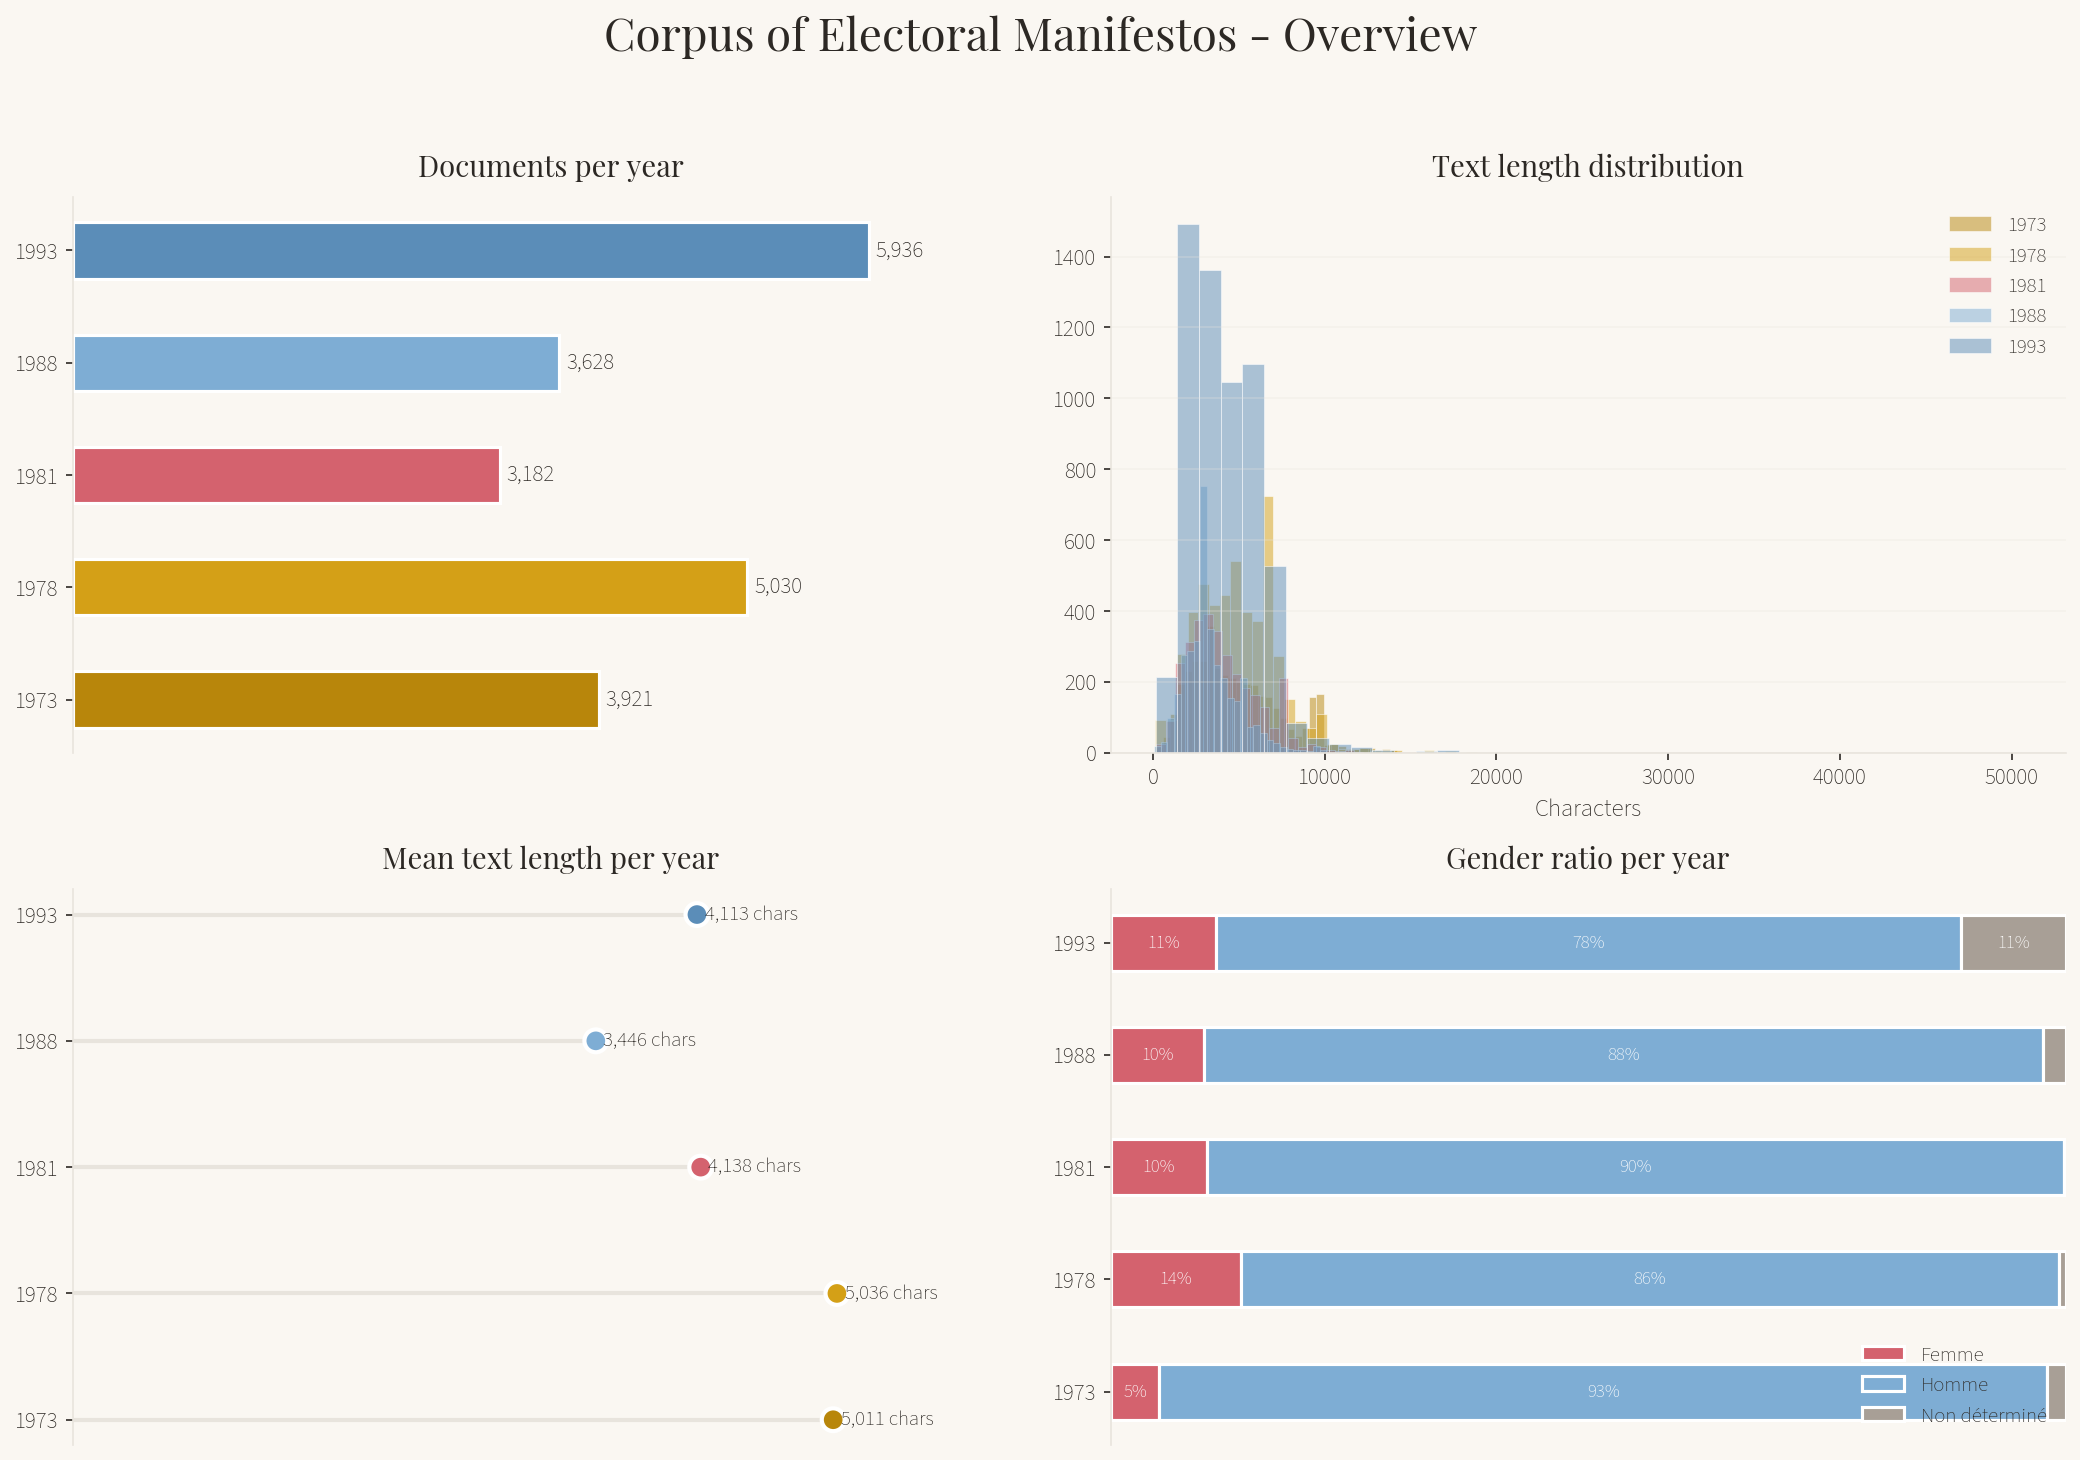

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Corpus of Electoral Manifestos - Overview",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

# Documents per year
ax = axes[0, 0]
year_counts = df['year'].value_counts().sort_index()
bars = ax.barh(year_counts.index, year_counts.values, height=0.5,
               color=[YEAR_COLORS.get(y, '#A89F96') for y in year_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, year_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax.set_title("Documents per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, year_counts.max() * 1.2)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# Text length distribution
ax = axes[0, 1]
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]['text_length']
    ax.hist(subset, bins=40, alpha=0.5, label=year,
            color=YEAR_COLORS.get(year, '#A89F96'), edgecolor='white', linewidth=0.5)
ax.set_title("Text length distribution", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlabel("Characters")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Mean text length (lollipop)
ax = axes[1, 0]
mean_lengths = df.groupby('year')['text_length'].mean().sort_index()
ax.hlines(mean_lengths.index, 0, mean_lengths.values, color=GRID_COLOR, linewidth=2)
ax.scatter(mean_lengths.values, mean_lengths.index, s=120, zorder=3,
           color=[YEAR_COLORS.get(y, '#A89F96') for y in mean_lengths.index],
           edgecolors='white', linewidth=2)
for y, val in zip(mean_lengths.index, mean_lengths.values):
    ax.text(val + 50, y, f'{val:,.0f} chars', va='center', fontsize=10, color=TEXT_COLOR)
ax.set_title("Mean text length per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, mean_lengths.max() * 1.25)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# Gender ratio
ax = axes[1, 1]
ct = pd.crosstab(df['year'], df['titulaire-sexe'], normalize='index') * 100
ct_sorted = ct.sort_index()
colors_sexe = {'homme': '#7EADD4', 'femme': ACCENT_COLOR}
col_names = ct_sorted.columns.tolist()
bottom = np.zeros(len(ct_sorted))
for col in col_names:
    color = colors_sexe.get(col, '#A89F96')
    ax.barh(ct_sorted.index, ct_sorted[col], left=bottom, height=0.5,
            label=col.capitalize(), color=color, edgecolor='white', linewidth=1.5)
    for i, (val, b) in enumerate(zip(ct_sorted[col], bottom)):
        if val > 5:
            ax.text(b + val/2, ct_sorted.index[i], f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += ct_sorted[col].values
ax.set_title("Gender ratio per year", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, 100)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.legend(frameon=False, loc='lower right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/exploration_base.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Corpus overview interpretation.**
The four-panel figure reveals the fundamental structure of our corpus:

- **Panel 1 (Documents per year)**: The growth in candidacies in 1993' elections reflects the fragmentation of the French party system. While earlier elections featured a bipolar left-right competition, later landscapes include ecological parties, extreme-right candidates in virtually every constituency, and a proliferation of micro-parties.
- **Panel 2 (Text length distribution)**: The distributions are roughly log-normal with a mode around 2,000-4,000 characters (1-2 printed pages). The consistency across years suggests that the physical format of the *profession de foi* (a standardized printed leaflet) constrains text length.
- **Panel 3 (Mean text length)**: Variations in mean length across years may reflect differences in campaign strategy, with some elections dominated by shorter, more telegraphic messaging.
- **Panel 4 (Gender ratio)**: The persistent male dominance underscores the pre-parity era. 

### 6.2 Dominant vocabulary per year

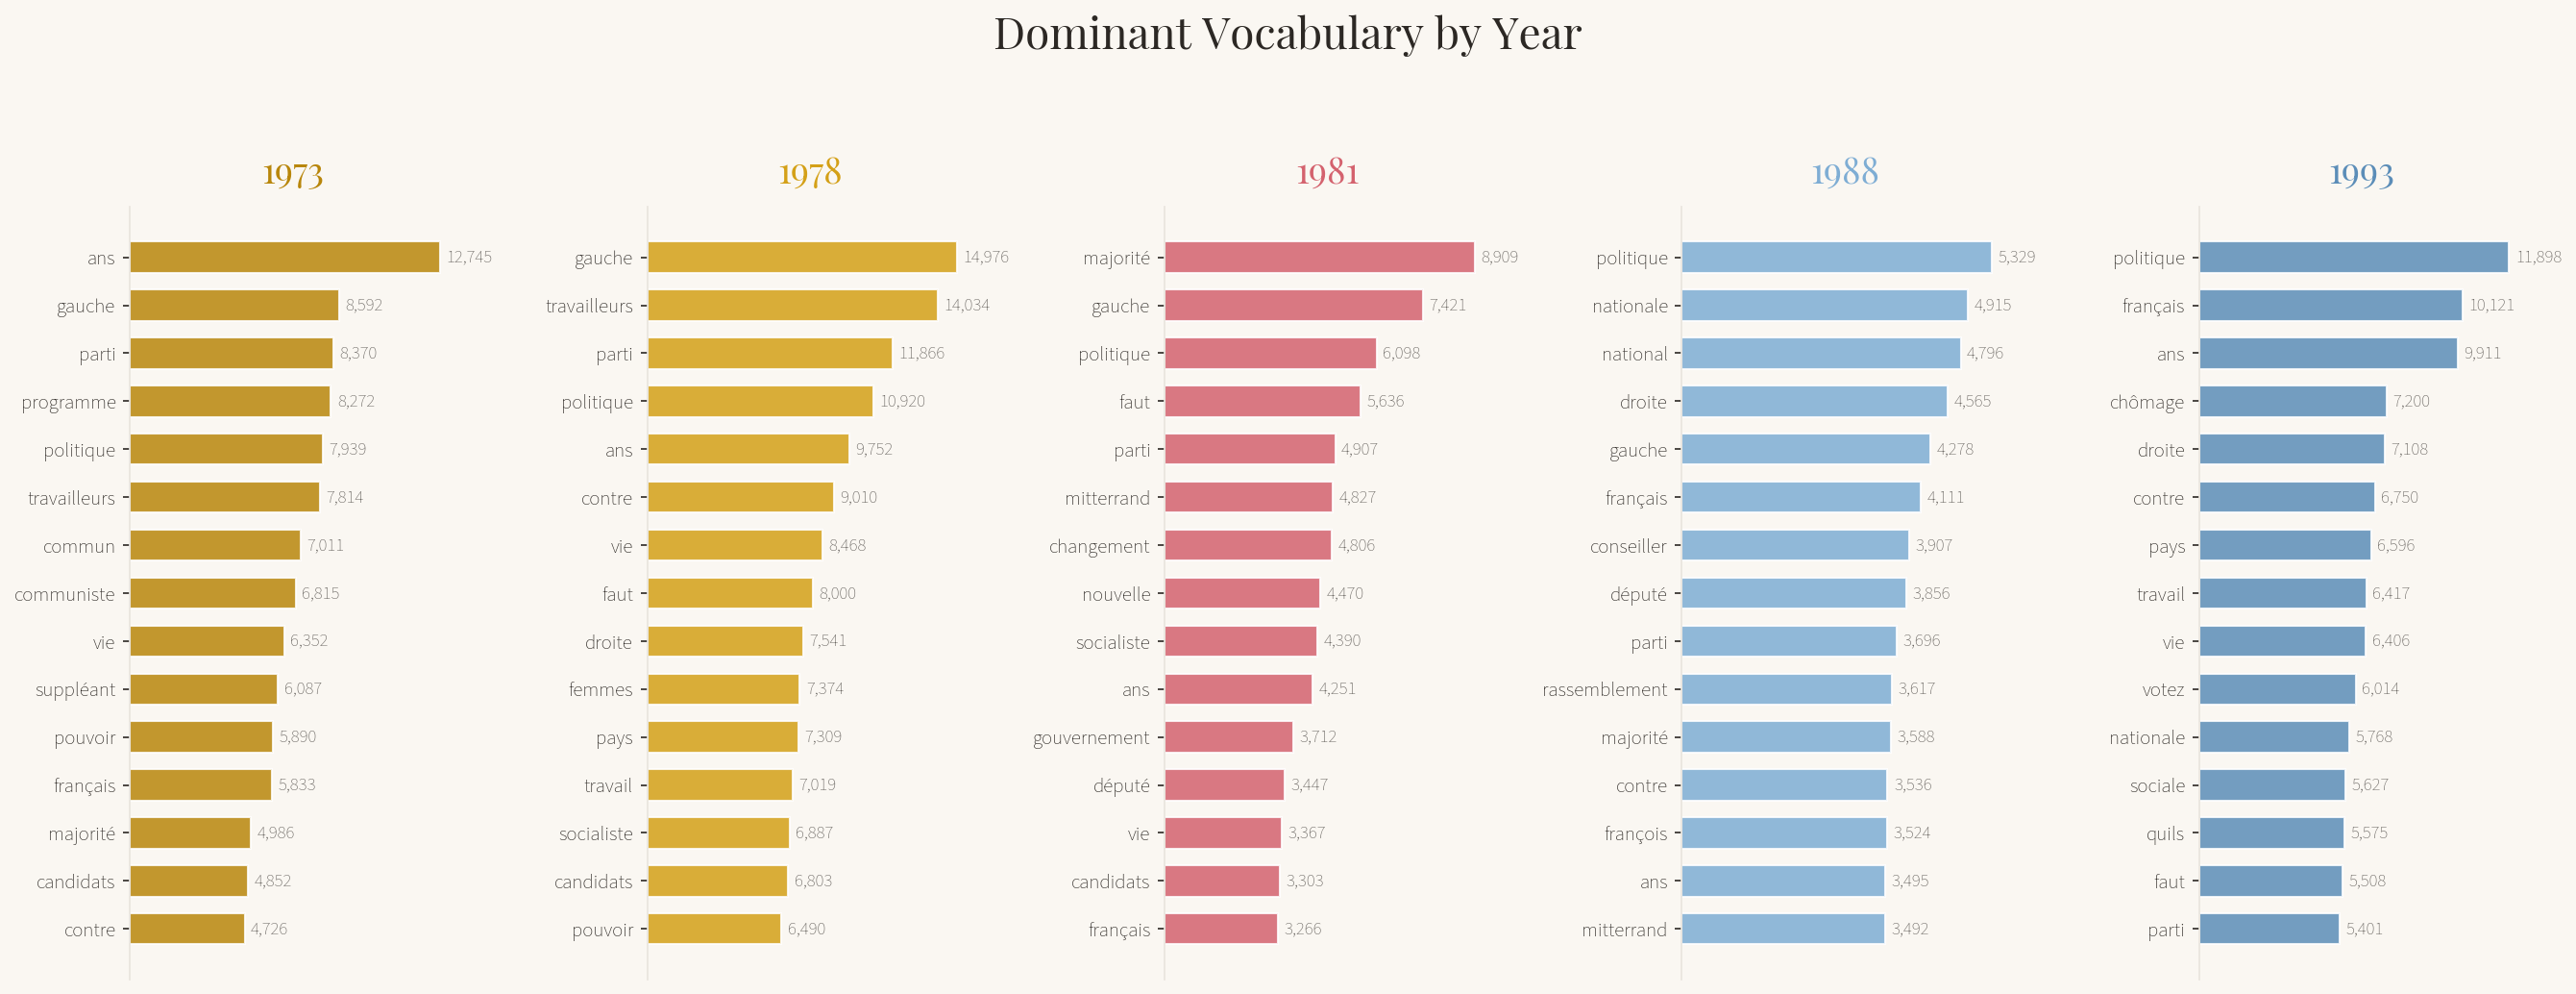

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 7))
fig.suptitle("Dominant Vocabulary by Year",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

for i, year in enumerate(sorted(df['year'].unique())):
    ax = axes[i]
    top = get_top_words(df[df['year'] == year], 15)
    words, counts = zip(*top)
    max_count = max(counts)
    color = YEAR_COLORS.get(year, '#A89F96')
    bars = ax.barh(range(len(words)), counts, height=0.65,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10, fontfamily=FONT_BODY)
    ax.invert_yaxis()
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=color, pad=12)
    ax.xaxis.set_visible(False)
    ax.spines['bottom'].set_visible(False)
    for bar, val in zip(bars, counts):
        ax.text(val + max_count * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color=TEXT_COLOR, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/top_mots_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The most frequent words are largely stable across elections: *politique*, *pays*, *travail*, *vie* dominate throughout. Shifts are visible in party-specific vocabulary (e.g., *changement* in 1981, *chômage* rising in 1993), which we will investigate further through topic modeling in Notebook 03.

---

## 7. Political Landscape

### 7.1 Political family distribution

We now visualize the distribution of candidacies across the six political families, excluding `non mentionné` and `Autre`.

=== Political family distribution (excluding non mentionné & Autre) ===

                   Candidacies  % of classified
famille_politique                              
Gauche radicale           4967             30.7
Gauche modérée            3370             20.9
Écologistes               1350              8.4
Centre                    1817             11.2
Droite                    3059             18.9
Extrême droite            1590              9.8

Total classified: 16,153 / 21,697 (74.4%)


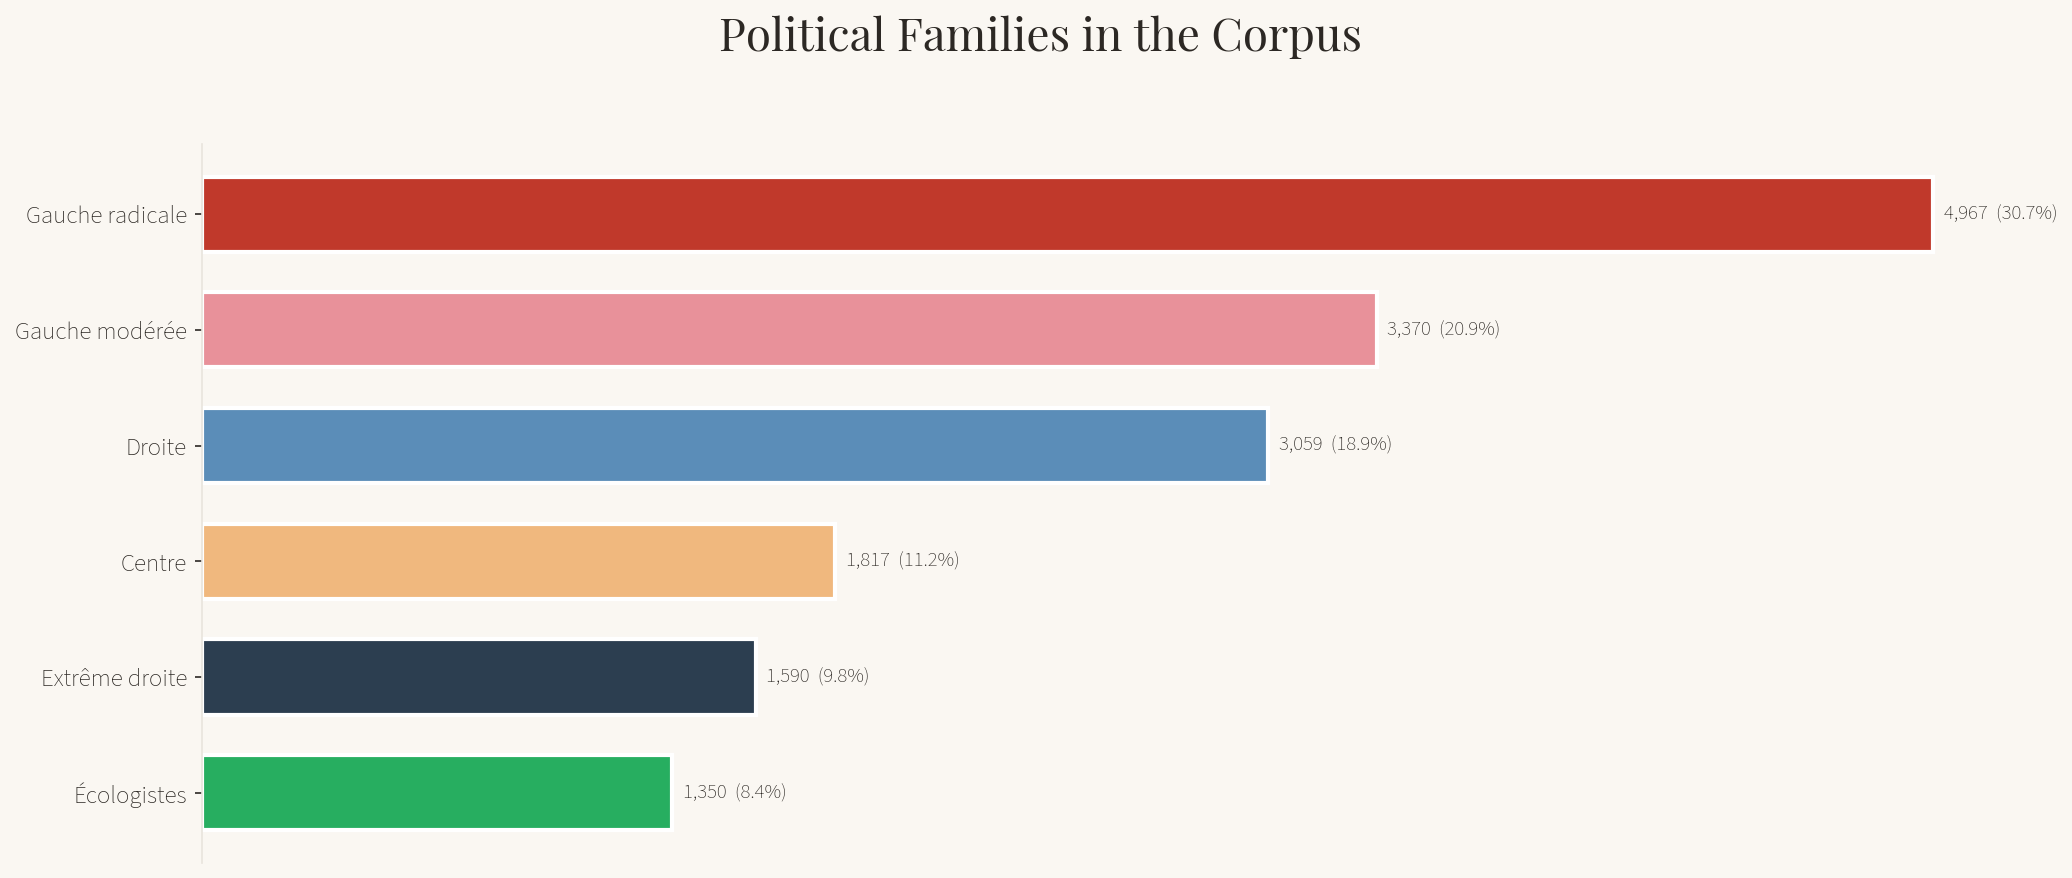

In [14]:
# Compute statistics table
family_counts = df_party['famille_politique'].value_counts().reindex(FAMILIES)
family_pct = (family_counts / len(df_party) * 100).round(1)
stats_landscape = pd.DataFrame({
    'Candidacies': family_counts,
    '% of classified': family_pct,
}).fillna(0)
print("=== Political family distribution (excluding non mentionné & Autre) ===\n")
print(stats_landscape.to_string())
print(f"\nTotal classified: {len(df_party):,} / {len(df):,} ({len(df_party)/len(df)*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Political Families in the Corpus",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

families_ordered = family_counts.sort_values(ascending=True).index.tolist()
counts_ordered = [family_counts[f] for f in families_ordered]
colors = [FAMILY_COLORS.get(f, '#A89F96') for f in families_ordered]
bars = ax.barh(range(len(families_ordered)), counts_ordered, height=0.65,
               color=colors, edgecolor='white', linewidth=2)
ax.set_yticks(range(len(families_ordered)))
ax.set_yticklabels(families_ordered, fontsize=12, fontfamily=FONT_BODY, fontweight='bold')
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val, fam in zip(bars, counts_ordered, families_ordered):
    pct = val / len(df_party) * 100
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/paysage_politique.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Interpretation.** The *gauche radicale* (PCF, LO, LCR, PSU) represents the largest family, reflecting the strong implantation of Communist and Trotskyist parties who fielded candidates in nearly every constituency. The *gauche modérée* (PS, MRG) follows, consistent with the PS's dominance of the reformist left during this period. The *droite* (RPR, gaullistes) and *extrême droite* (FN) show substantial presence, while the *centre* (UDF) and *écologistes* are smaller families, the latter growing significantly over the period as we will see below.

### 7.2 Political family evolution over time

=== Family share (%) by year ===

famille_politique  Gauche radicale  Gauche modérée  Écologistes  Centre  Droite  Extrême droite
year                                                                                           
1973                          32.6            22.5          0.0    16.3    25.0             3.6
1978                          39.2            26.3          2.2     6.7    20.1             5.5
1981                          36.6            34.3          1.8     9.7    15.2             2.4
1988                          27.6            12.8          1.2    11.6    19.6            27.1
1993                          20.6            11.7         26.2    12.0    15.2            14.3


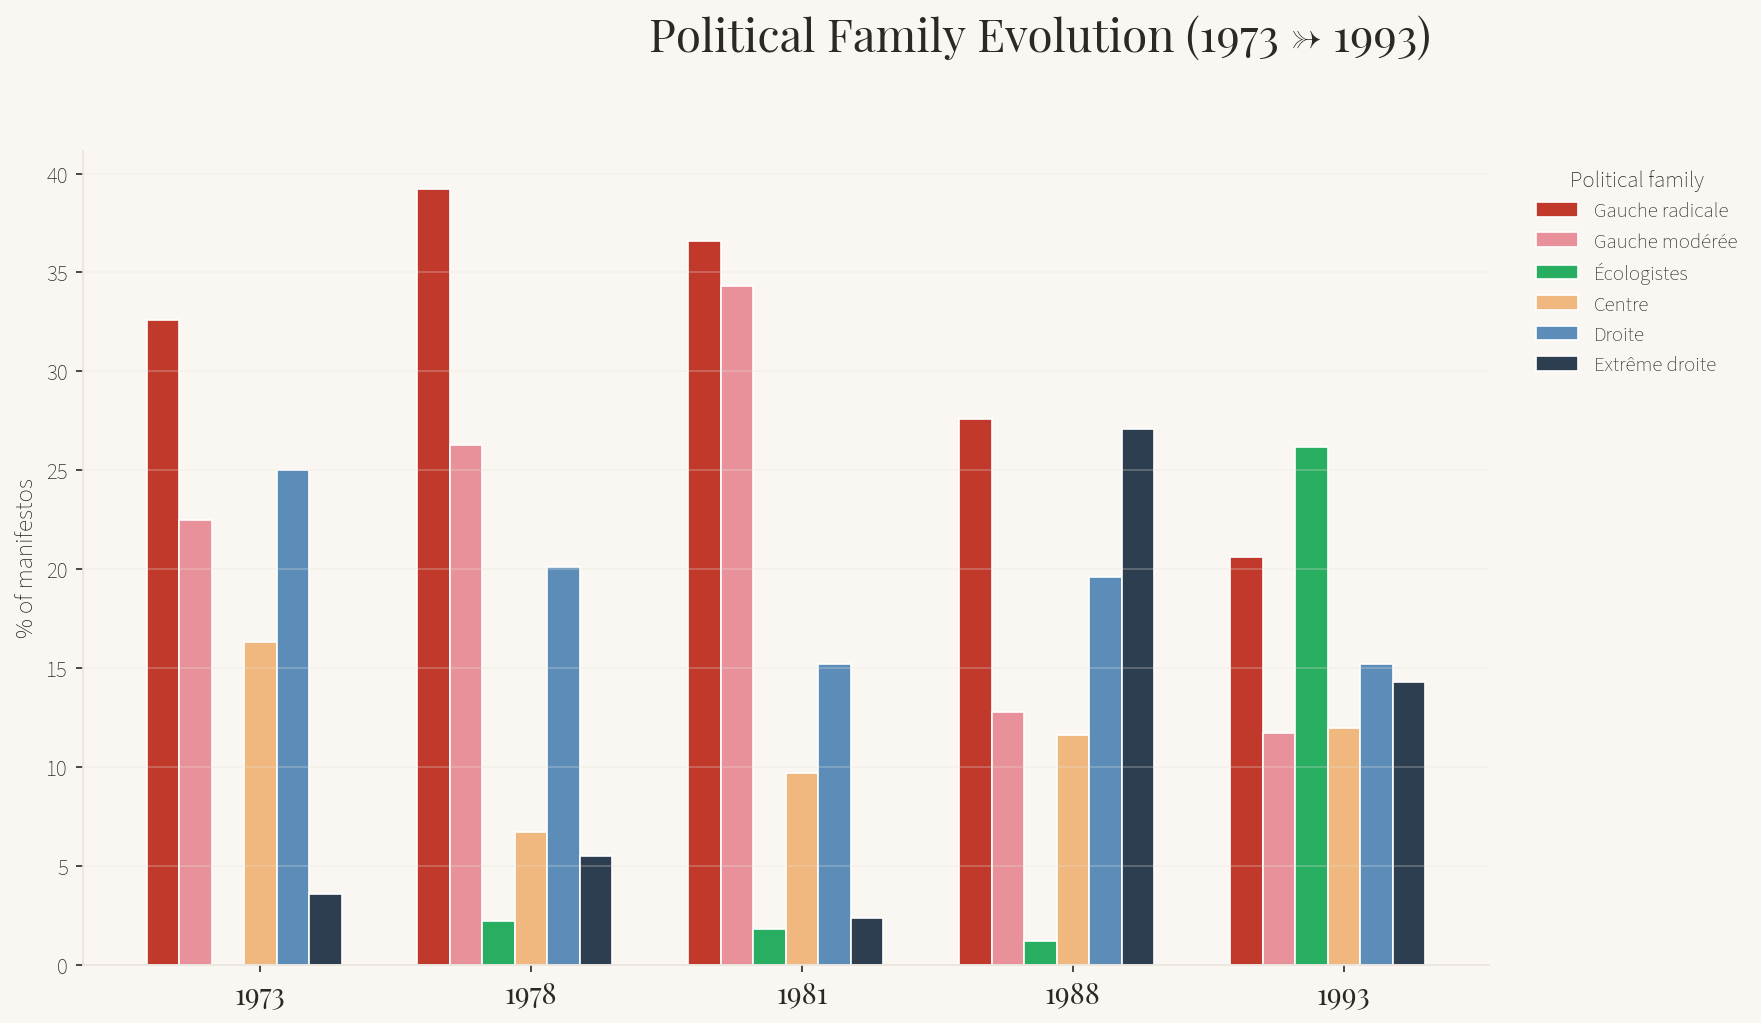

In [15]:
# Statistics table: family share per year
ct_evolution = pd.crosstab(df_party['year'], df_party['famille_politique'], normalize='index') * 100
ct_evolution = ct_evolution.reindex(columns=FAMILIES, fill_value=0).round(1)
print("=== Family share (%) by year ===\n")
print(ct_evolution.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Political Family Evolution (1973 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

ct = ct_evolution
x = np.arange(len(ct.index))
width = 0.12
n_fam = len(FAMILIES)

for i, fam in enumerate(FAMILIES):
    if fam not in ct.columns:
        continue
    offset = (i - n_fam/2) * width
    color = FAMILY_COLORS.get(fam, '#A89F96')
    ax.bar(x + offset, ct[fam], width=width, label=fam,
           color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% of manifestos", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          fontsize=10, title="Political family",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 0.85, 0.93])
plt.savefig("../data/evolution_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Political evolution interpretation.** The temporal evolution reveals major structural shifts in the French party system:

1. **Decline of the radical left**: The *gauche radicale*'s share shrinks over the period, driven by the PCF's electoral decline (Lavau, 1981) and the marginalization of far-left movements after Mitterrand's 1981 victory absorbed much of the left-wing electorate.
2. **Rise of the far right**: The *extrême droite* surges from marginal presence to a major force by 1993, with the FN fielding candidates in nearly every constituency, a "nationalization" of its candidacy strategy (Perrineau, 1997).
3. **Emergence of ecologists**: The *écologistes* grow rapidly, reflecting the institutionalization of the environmental movement after the 1992 Rio Earth Summit and the success of Brice Lalonde's *Génération écologie*.
4. **Stability of the moderate left and right**: Both the *gauche modérée* and *droite* maintain relatively stable shares, confirming the persistence of the bipolar structure underlying the French party system.

---

## 8. Socio-Professional Profile of Candidates

The `titulaire-profession` field was classified into 15 PCS categories using BERT zero-shot classification (Section 4.2). We now analyze the resulting distribution.

### 8.1 PCS category distribution

=== PCS category distribution ===

                                        Count     %
profession_pcs                                     
Non renseigné                           10011  46.1
Enseignant, chercheur, universitaire     2716  12.5
Profession juridique                     2085   9.6
Employé, fonctionnaire                   1925   8.9
Ouvrier                                  1548   7.1
Cadre supérieur, ingénieur               1050   4.8
Cadre moyen, technicien                   680   3.1
Profession commerciale, vente             616   2.8
Agriculteur, exploitant agricole          484   2.2
Journaliste, artiste, communication       163   0.8
Profession religieuse                     134   0.6
Profession médicale ou paramédicale        91   0.4
Artisan, commerçant, chef d'entreprise     88   0.4
Permanent politique ou syndical            63   0.3
Militaire, policier, sécurité              43   0.2


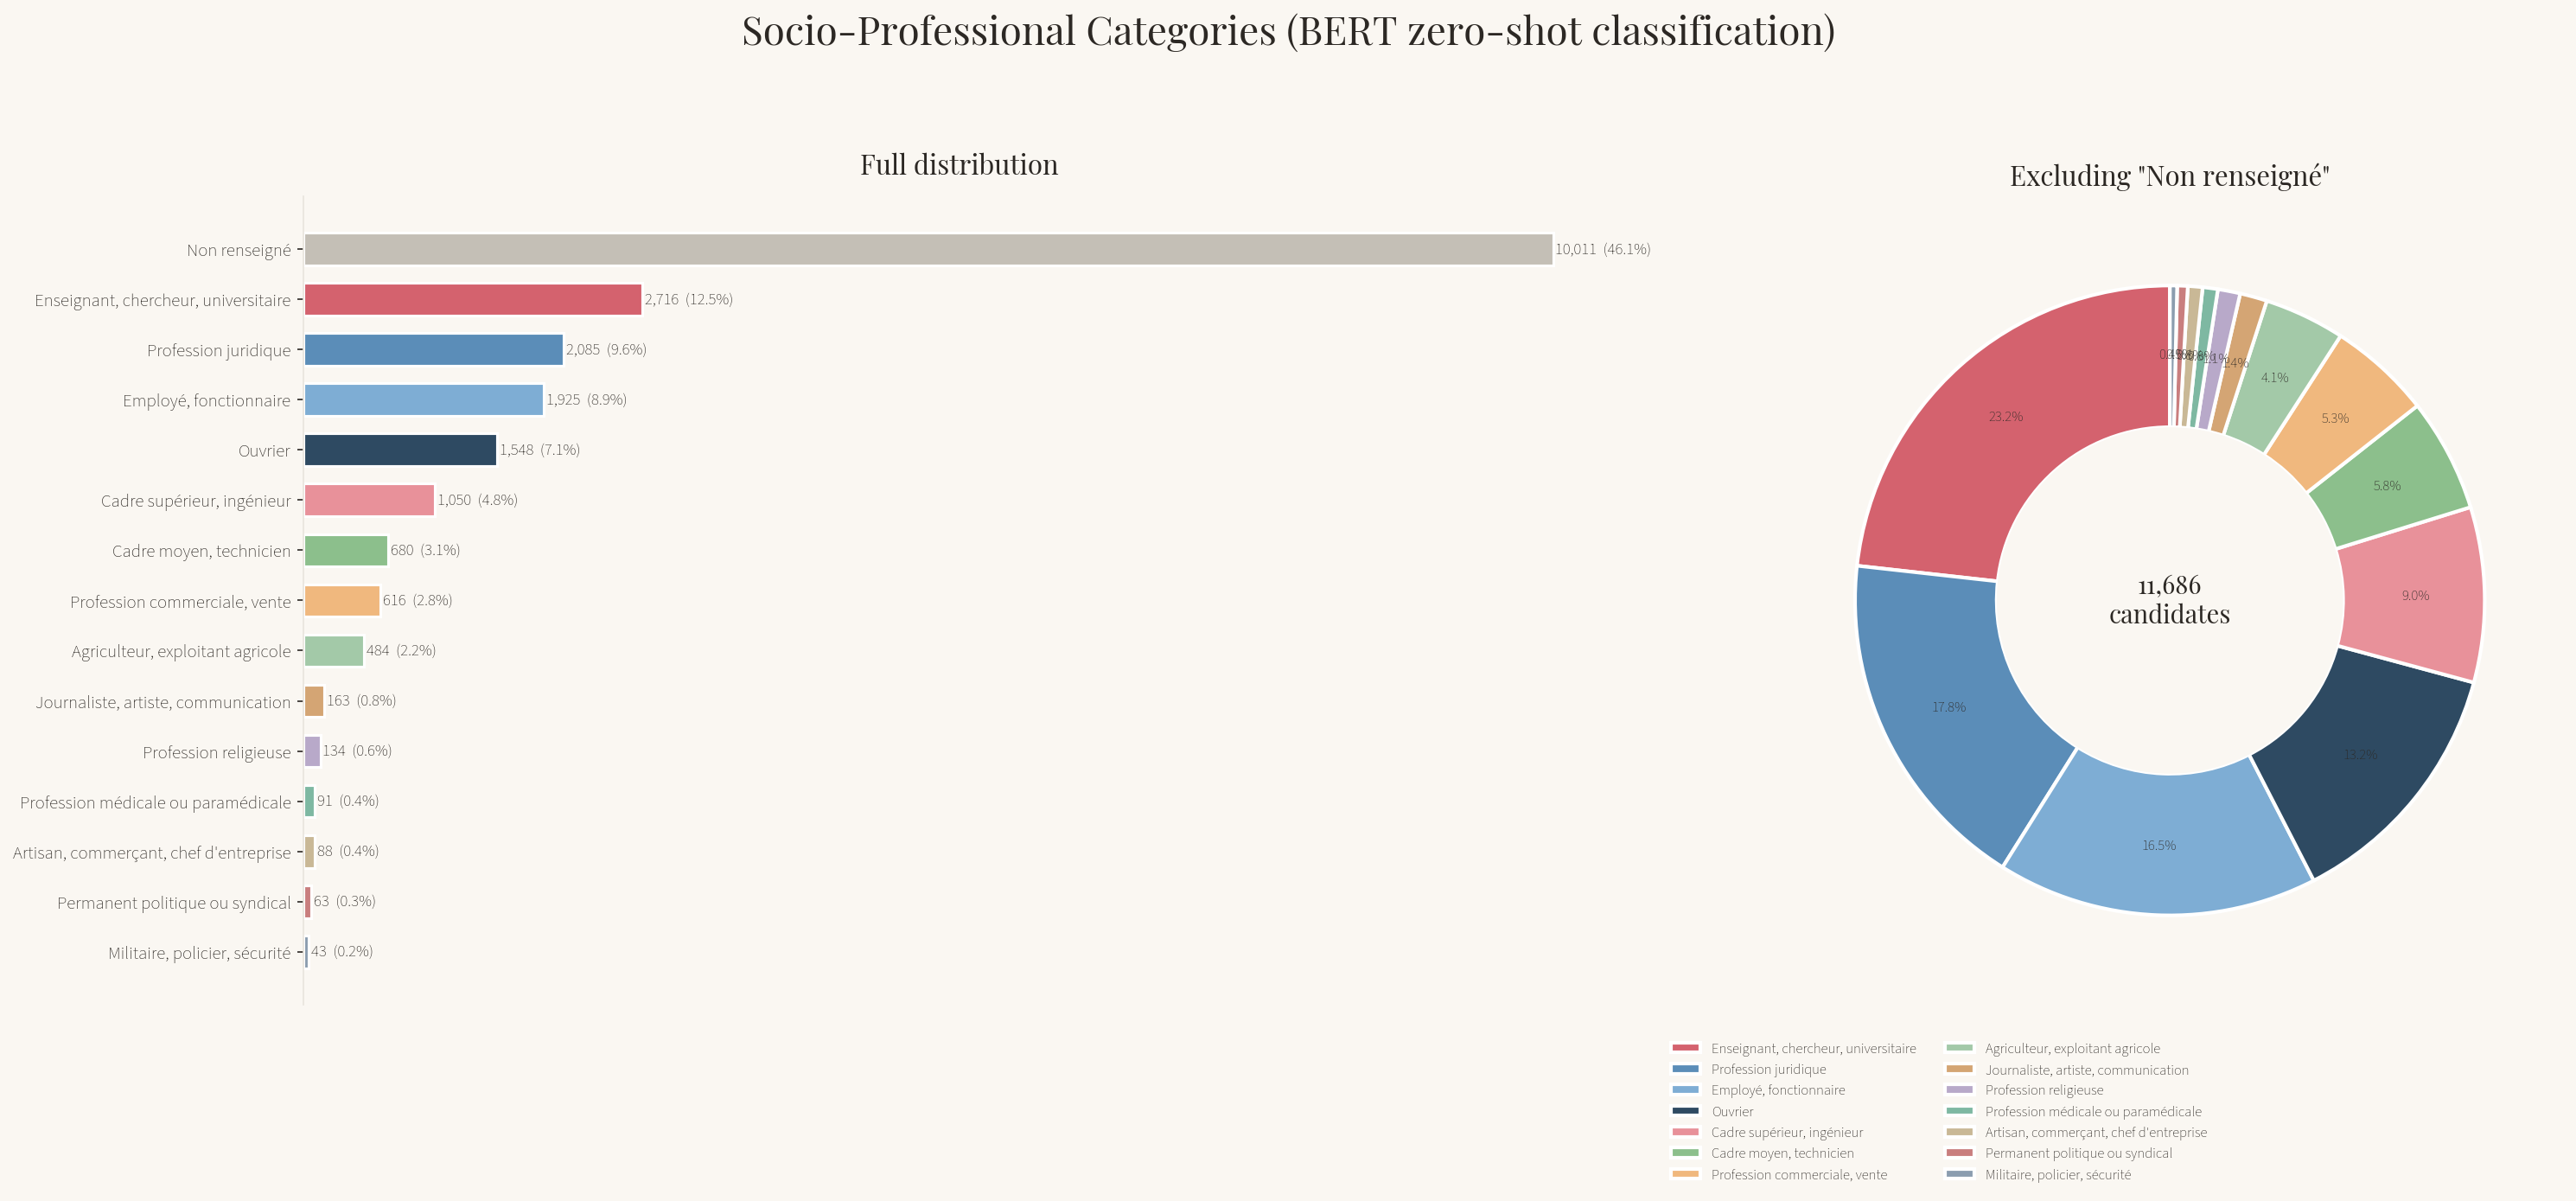

In [16]:
# Statistics table
pcs_counts = df['profession_pcs'].value_counts()
pcs_pct = (pcs_counts / len(df) * 100).round(1)
stats_pcs = pd.DataFrame({'Count': pcs_counts, '%': pcs_pct})
print("=== PCS category distribution ===\n")
print(stats_pcs.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={'width_ratios': [2, 1.2]})
fig.suptitle("Socio-Professional Categories (BERT zero-shot classification)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

ax = axes[0]
categories = pcs_counts.index.tolist()
values = pcs_counts.values
colors = [PCS_COLORS.get(c, '#A89F96') for c in categories]
bars = ax.barh(range(len(categories)), values, height=0.65,
               color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
for bar, val in zip(bars, values):
    pct = val / len(df) * 100
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)
ax.set_title("Full distribution", fontfamily=FONT_TITLE, fontsize=15, pad=12)

ax2 = axes[1]
pcs_filled = pcs_counts.drop('Non renseigné', errors='ignore')
labels = pcs_filled.index.tolist()
sizes = pcs_filled.values
colors_donut = [PCS_COLORS.get(c, '#A89F96') for c in labels]
wedges, texts, autotexts = ax2.pie(
    sizes, labels=None, autopct='%1.1f%%', startangle=90,
    colors=colors_donut, pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color(TEXT_COLOR)
    autotext.set_fontweight('bold')
ax2.legend(wedges, labels, loc='center left', bbox_to_anchor=(-0.15, -0.15),
           fontsize=8, frameon=False, ncol=2)
ax2.set_title('Excluding "Non renseigné"', fontfamily=FONT_TITLE, fontsize=15, pad=12)
centre_circle = plt.Circle((0, 0), 0.55, fc=BG_COLOR)
ax2.add_artist(centre_circle)
n_filled = pcs_filled.sum()
ax2.text(0, 0, f'{n_filled:,}\ncandidates', ha='center', va='center',
         fontsize=14, fontweight='bold', fontfamily=FONT_TITLE, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("../data/professions_pcs_bert.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The BERT-based classification reveals a strong over-representation of **teachers and researchers** (~12% of classified candidates), followed by **legal professionals**, **employees/civil servants**, and **blue-collar workers**. This is consistent with the known sociological profile of French political candidates, where the public sector is heavily represented.

---

## 9. Advanced Cross-Analyses

This section combines political family with socio-demographic metadata to reveal structural patterns.

### 9.1 Socio-professional profile by political family (heatmap)

=== PCS × Political family (% of each family's candidates) ===

famille_politique                       Gauche radicale  Gauche modérée  Écologistes  Centre  Droite  Extrême droite
profession_pcs                                                                                                      
Agriculteur, exploitant agricole                    2.8             2.7          5.5     4.2     5.4             6.0
Artisan, commerçant, chef d'entreprise              0.0             0.4          0.3     1.3     1.4             1.7
Cadre moyen, technicien                             5.8             6.7          5.3     5.7     6.8             4.1
Cadre supérieur, ingénieur                          7.6            10.4         10.4     7.8     9.3            10.9
Employé, fonctionnaire                             19.8            14.1         18.2    11.5    15.1            16.8
Enseignant, chercheur, universitaire               18.8            34.6         28.7    26.7    22.2            13.0


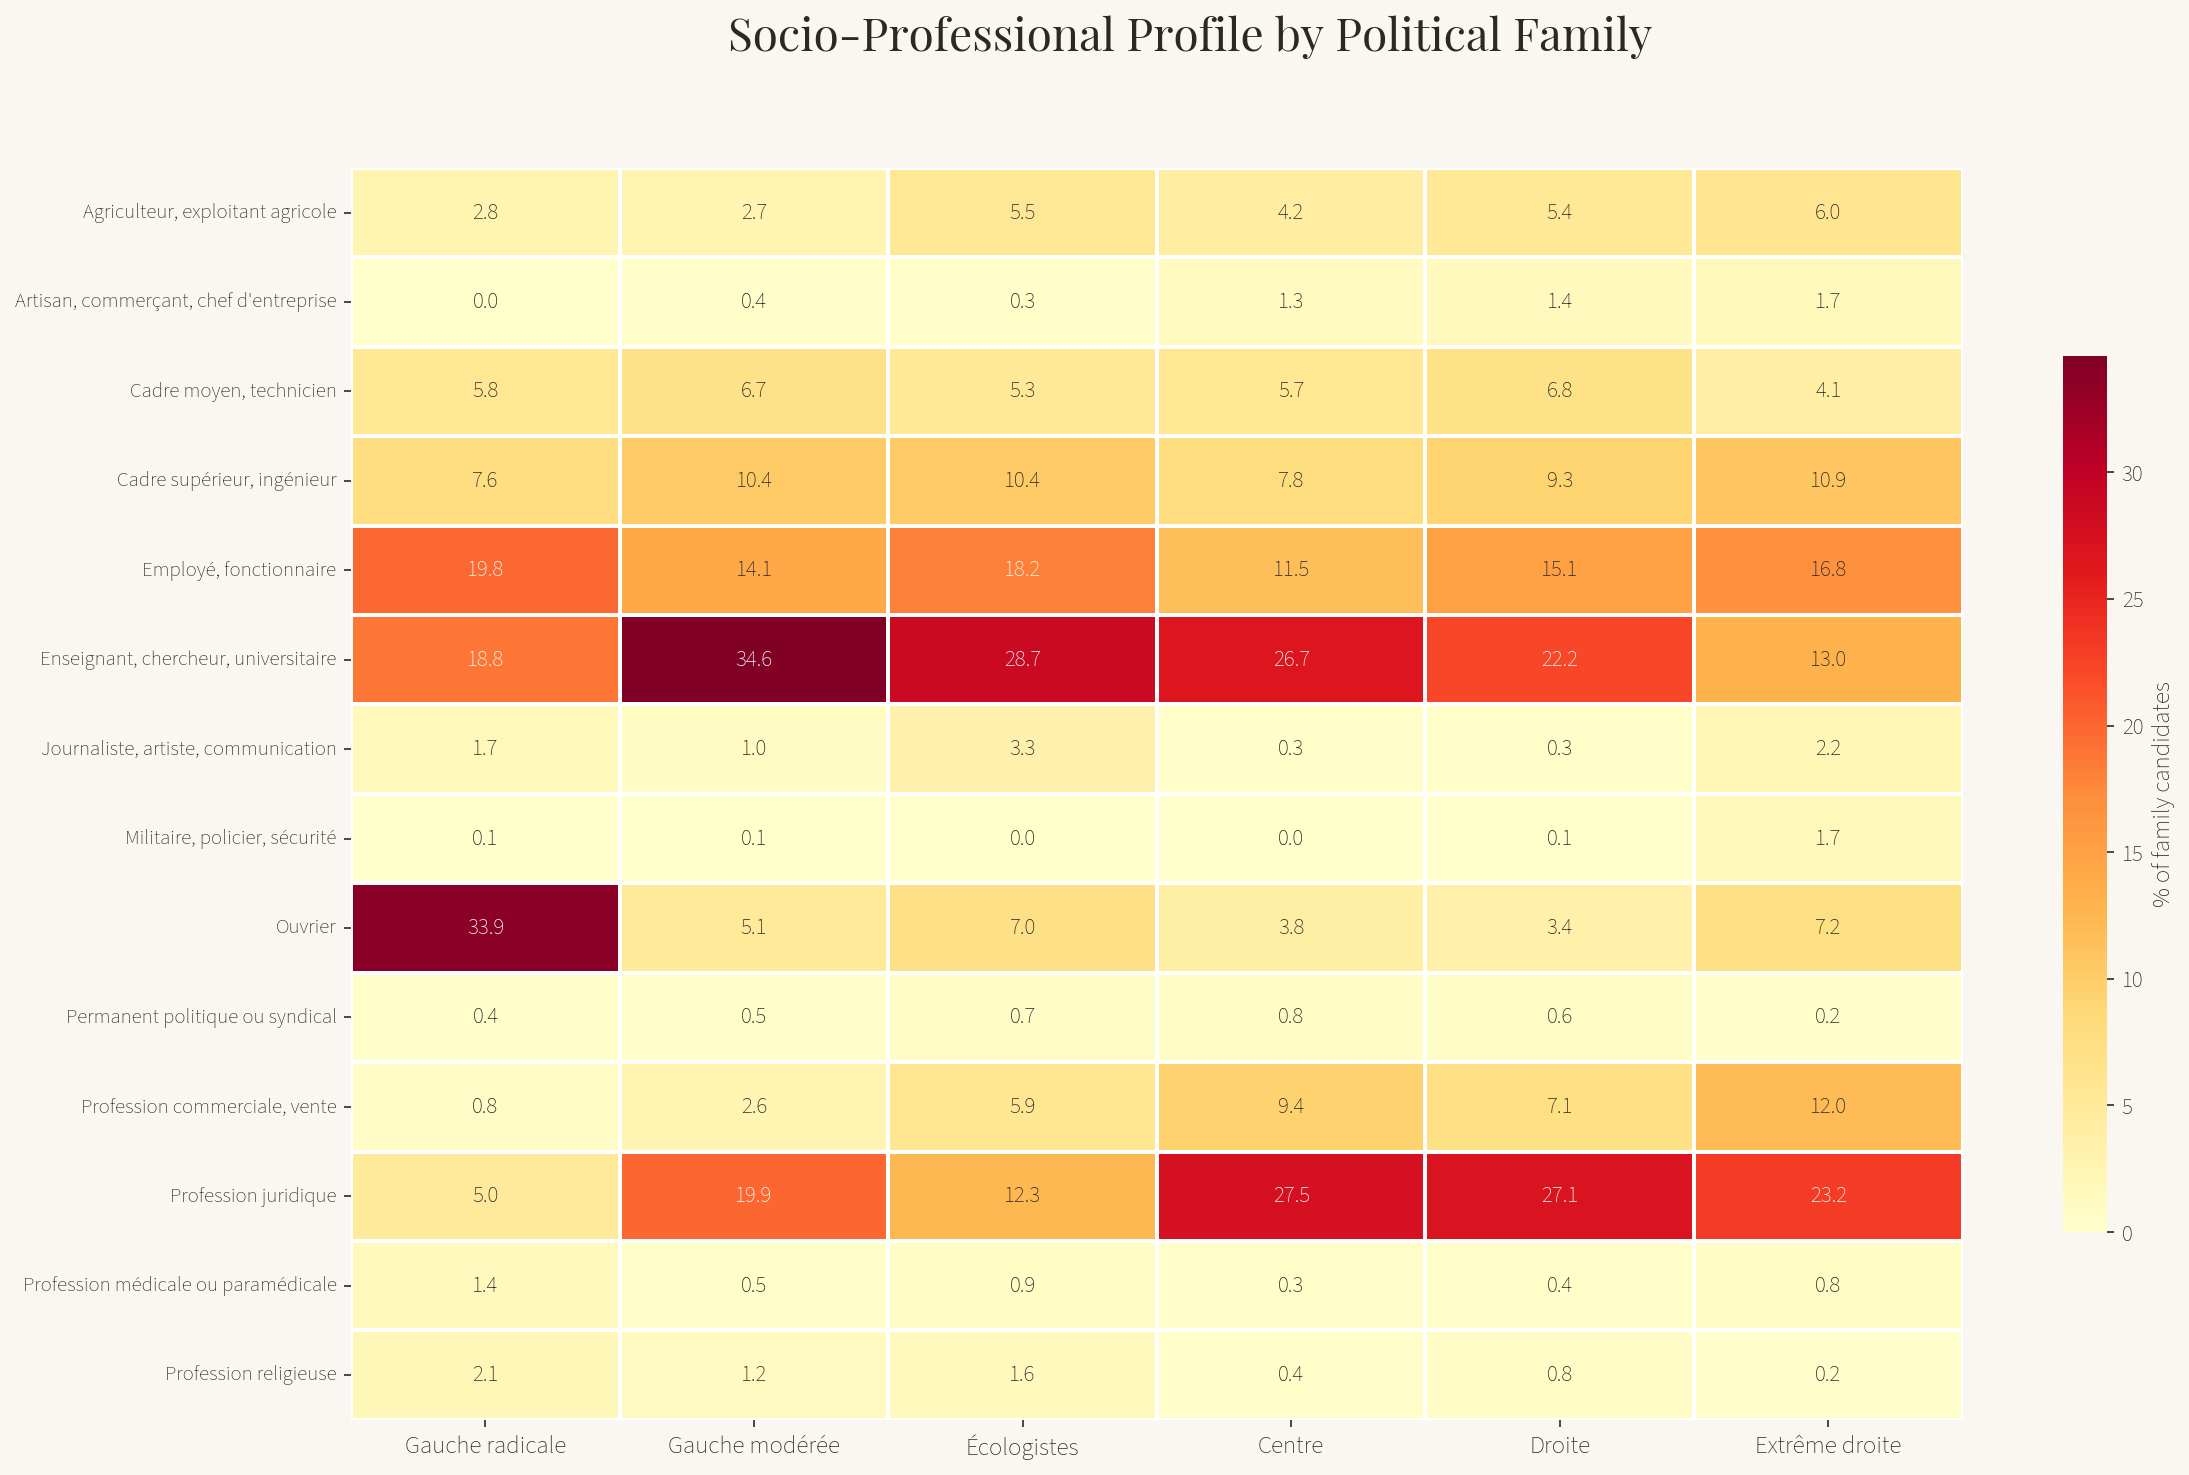

In [17]:

df_party = df[df['famille_politique'].notna() & (df['famille_politique'] != 'Autre')].copy()

# Statistics table
df_cross = df_party[df_party['profession_pcs'] != 'Non renseigné'].copy()
ct_heatmap = pd.crosstab(df_cross['profession_pcs'], df_cross['famille_politique'], normalize='columns') * 100
ct_heatmap = ct_heatmap.reindex(columns=FAMILIES, fill_value=0).round(1)
print("=== PCS × Political family (% of each family's candidates) ===\n")
print(ct_heatmap.to_string())

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
fig.suptitle("Socio-Professional Profile by Political Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

sns.heatmap(ct_heatmap, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': '% of family candidates', 'shrink': 0.7})
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=12, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/heatmap_pcs_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Interpretation of the PCS-family heatmap.** This cross-tabulation reveals the socio-professional recruitment base of each political family, a key variable in French political sociology (Gaxie, 1978; Offerlé, 1999):

- **Gauche radicale**: Draws heavily from **blue-collar workers** (ouvriers) and employees, consistent with the PCF's and LO's historical role as parties of the working class and public-sector union base (CGT).
- **Gauche modérée**: Dominated by **teachers and researchers**, reflecting the PS's deep roots in the *Éducation nationale*, the classic "party of teachers" characterization.
- **Droite / Centre**: Recruit from **senior executives, engineers**, and legal professionals, reflecting their base among the economic and professional bourgeoisie.
- **Extrême droite**: Shows a more heterogeneous professional profile, consistent with the FN's catch-all populist positioning that cuts across traditional class lines.
- **Écologistes**: Over-represent teachers and liberal professions, consistent with the "new middle class" thesis (Inglehart, 1977) linking post-materialist values to higher-education professionals.

/tmp/ipykernel_9555/1434832078.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fem_rate = df_sex.groupby(['year', 'famille_politique']).apply(


=== Feminization rate (%) by family and year ===

famille_politique  Gauche radicale  Gauche modérée  Écologistes  Centre  Droite  Extrême droite
year                                                                                           
1973                          10.6             2.1          0.0     2.9     2.9             8.3
1978                          25.4             6.1         18.1     5.5     4.0            16.4
1981                          19.0             8.4         20.0     1.3     3.3            12.1
1988                          14.4             8.9         16.7     3.4     6.8            10.9
1993                          18.4            10.3         21.2     6.5     9.4            11.8


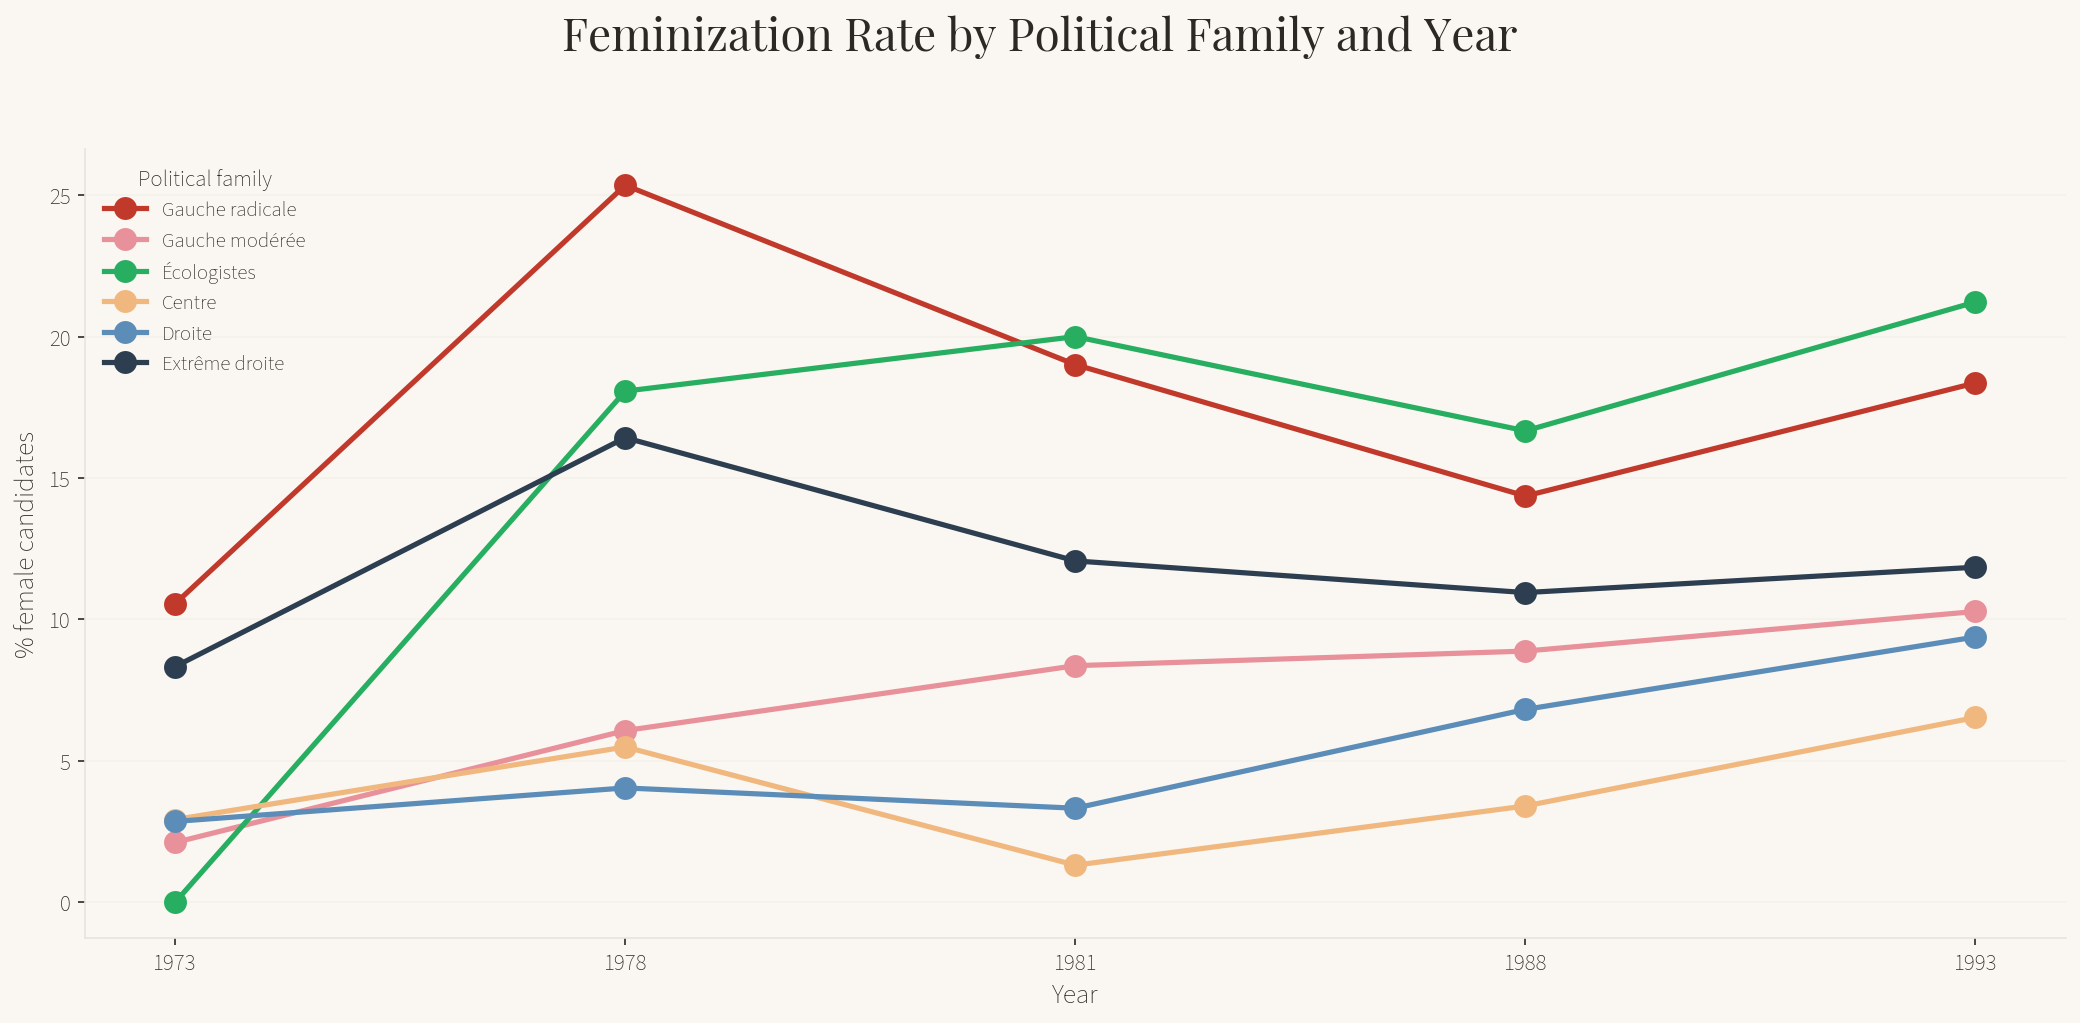

In [18]:
# Statistics table
df_sex = df_party[df_party['titulaire-sexe'] != 'non déterminé'].copy()
fem_rate = df_sex.groupby(['year', 'famille_politique']).apply(
    lambda x: (x['titulaire-sexe'] == 'femme').mean() * 100
).reset_index(name='taux_femmes')
fem_pivot = fem_rate.pivot(index='year', columns='famille_politique', values='taux_femmes')
fem_pivot = fem_pivot.reindex(columns=FAMILIES, fill_value=0).round(1)
print("=== Feminization rate (%) by family and year ===\n")
print(fem_pivot.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Feminization Rate by Political Family and Year",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

for fam in FAMILIES:
    data = fem_rate[fem_rate['famille_politique'] == fam]
    if data.empty:
        continue
    ax.plot(data['year'], data['taux_femmes'], marker='o', markersize=10,
            linewidth=2.5, label=fam, color=FAMILY_COLORS.get(fam, '#A89F96'))

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% female candidates", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=10, title="Political family",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/feminisation_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Feminization analysis.** Before the *loi sur la parité* (2000), parties had no legal obligation to present female candidates. The visualization reveals:

- All political families remain below 20% female candidates, far from parity.
- Left-wing families (*gauche radicale* and *gauche modérée*) tend to show slightly higher feminization rates than the right, consistent with the literature on gender and political engagement in France (Sineau, 2001).
- The *extrême droite* shows variable rates, reflecting the FN's evolving organizational structure during its period of rapid growth.
- The modest upward trend visible over time prefigures the stronger push toward parity that would culminate in the constitutional reform of 1999.

### 9.3 Age distribution by political family (violin plot)

=== Age statistics by political family ===

                   mean  median   std  count
famille_politique                           
Gauche radicale    36.2    34.0   9.6   2019
Gauche modérée     41.6    41.0   8.0   1310
Écologistes        41.4    41.0   7.8    528
Centre             42.9    43.0   8.6    616
Droite             43.1    43.0   9.2    970
Extrême droite     43.9    44.0  11.7    978


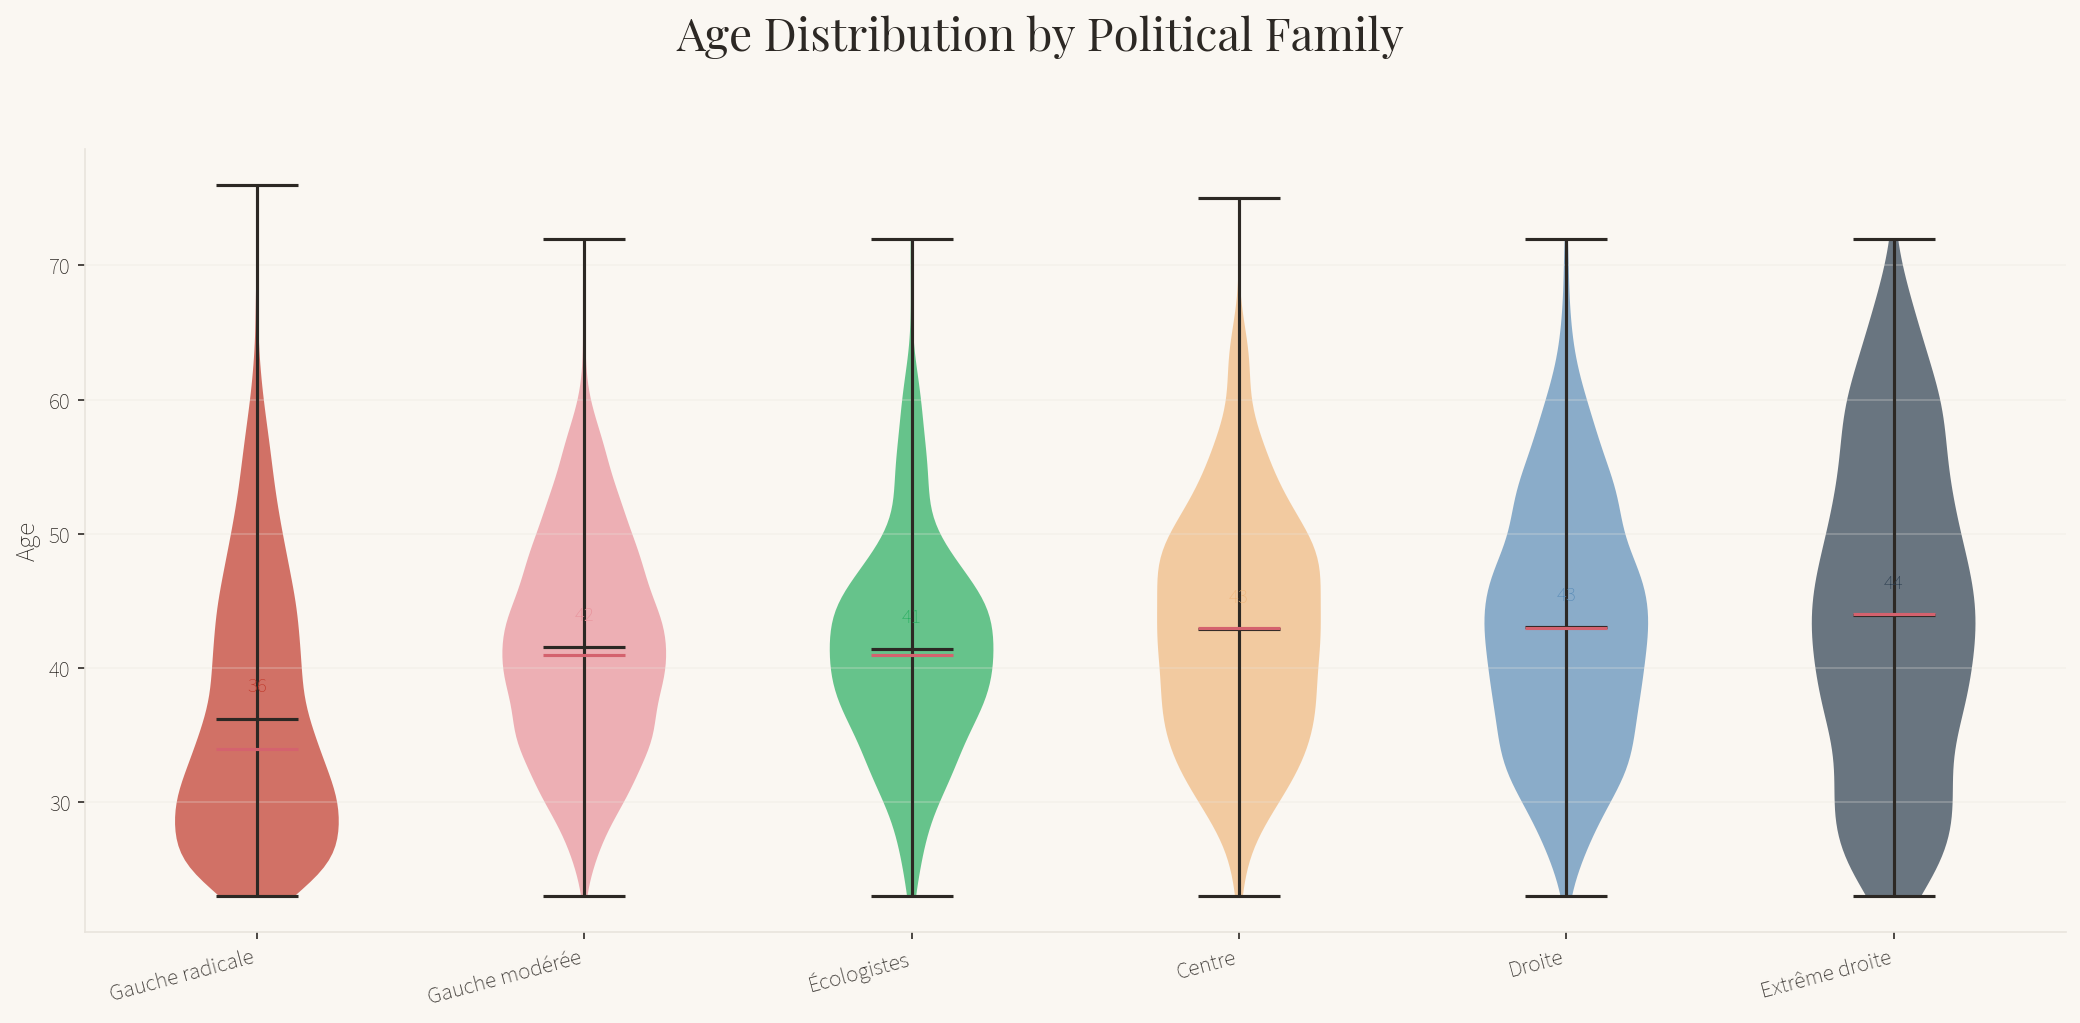

In [19]:
# Statistics table
df_age = df_party.copy()
df_age['age_num'] = pd.to_numeric(df_age['titulaire-age-calcule'], errors='coerce')
df_age = df_age.dropna(subset=['age_num'])
df_age = df_age[(df_age['age_num'] > 18) & (df_age['age_num'] < 100)]

age_stats = df_age.groupby('famille_politique')['age_num'].agg(['mean', 'median', 'std', 'count'])
age_stats = age_stats.reindex(FAMILIES).round(1)
print("=== Age statistics by political family ===\n")
print(age_stats.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Age Distribution by Political Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

order = [f for f in FAMILIES if f in df_age['famille_politique'].unique()]
parts = ax.violinplot(
    [df_age[df_age['famille_politique'] == f]['age_num'].values for f in order],
    positions=range(len(order)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(FAMILY_COLORS[order[i]])
    pc.set_alpha(0.7)

parts['cmeans'].set_color(TEXT_COLOR)
parts['cmedians'].set_color('#D4626E')
parts['cmins'].set_color(TEXT_COLOR)
parts['cmaxes'].set_color(TEXT_COLOR)
parts['cbars'].set_color(TEXT_COLOR)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=11, rotation=15, ha='right')
ax.set_ylabel("Age", fontsize=13)
ax.grid(axis='y', alpha=0.3)

for i, fam in enumerate(order):
    mean_age = df_age[df_age['famille_politique'] == fam]['age_num'].mean()
    ax.text(i, mean_age + 2, f'{mean_age:.0f}', ha='center', fontsize=10,
            fontweight='bold', color=FAMILY_COLORS[fam])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/age_partis_violin.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Age distribution.** The age profiles vary moderately across political families. The *gauche radicale* tends to skew slightly younger, reflecting the student and activist recruitment base of far-left movements. The *droite* and *centre* show slightly older median ages, consistent with the established professional profiles (executives, lawyers) of their candidates. The high proportion of missing age data (61% overall) limits the strength of these conclusions.

### 9.4 Geographic distribution (top 25 departments)

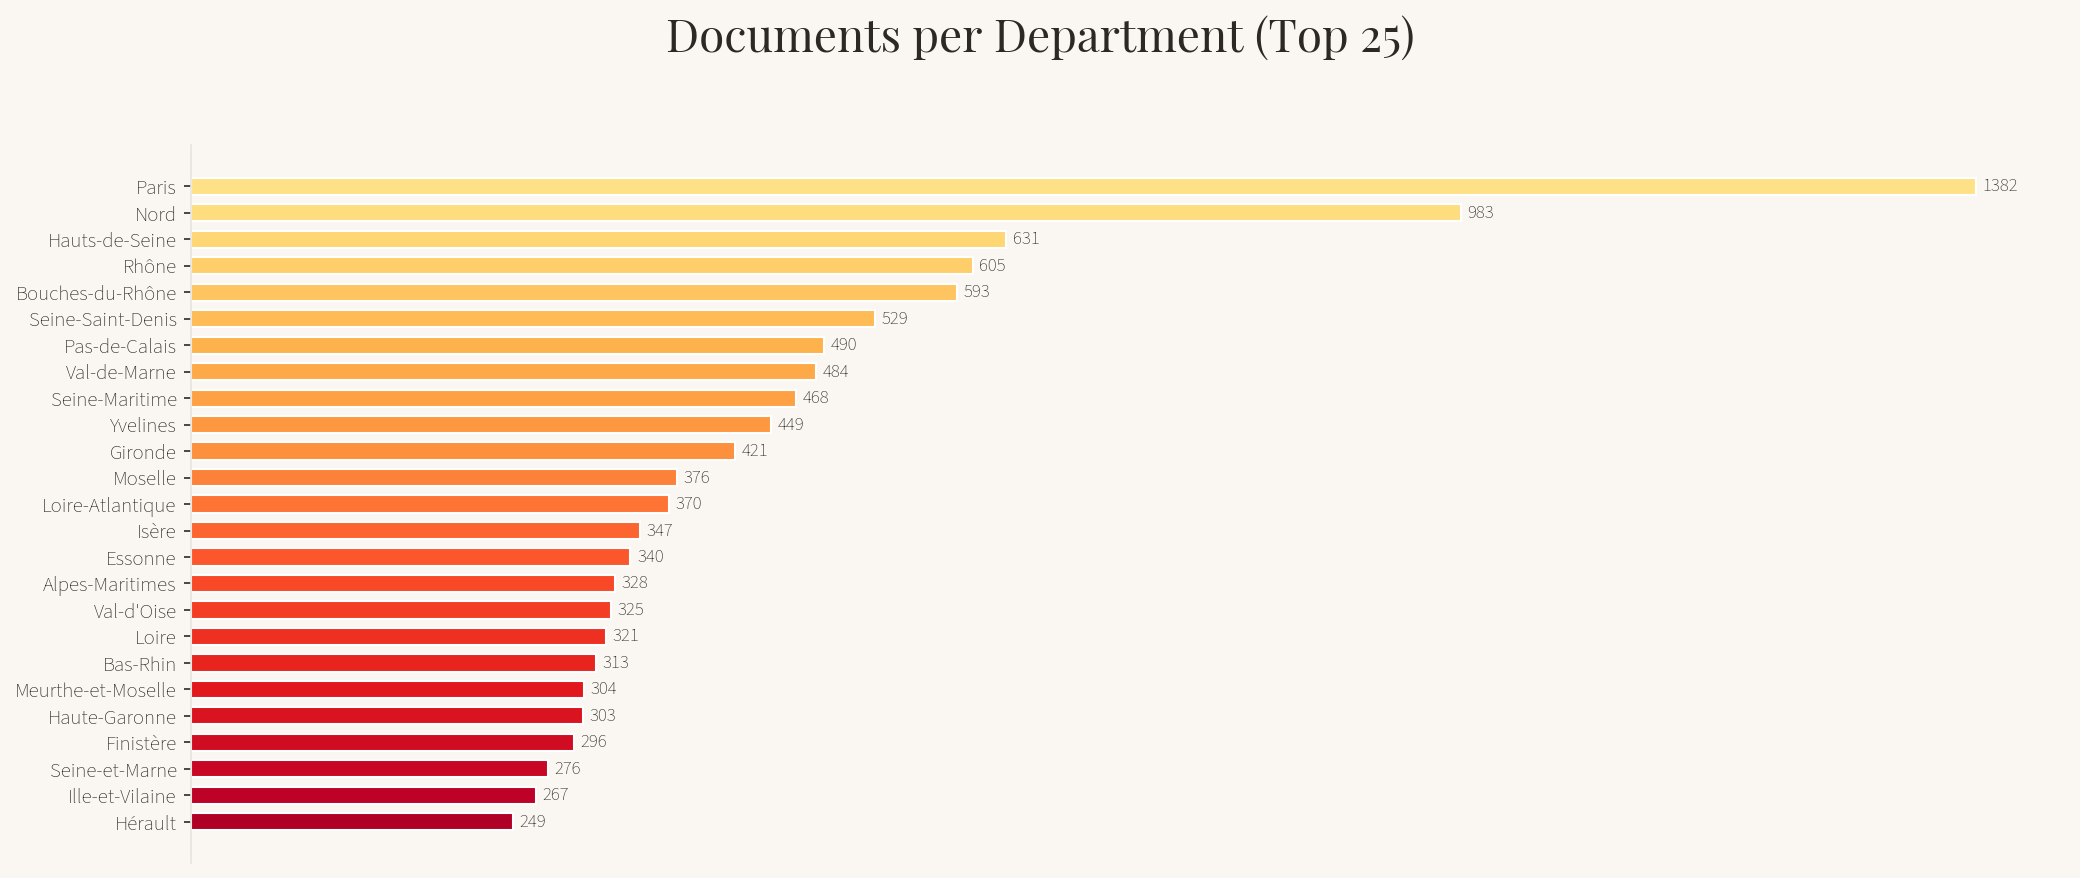

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Documents per Department (Top 25)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

dept_counts = df['departement-nom'].value_counts().head(25)
colors_dept = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(dept_counts)))

bars = ax.barh(range(len(dept_counts)), dept_counts.values, height=0.65,
               color=colors_dept, edgecolor='white', linewidth=1)
ax.set_yticks(range(len(dept_counts)))
ax.set_yticklabels(dept_counts.index, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, dept_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/departements_top25.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Geographic distribution.** The most populated departments (Nord, Paris, Bouches-du-Rhône, Rhône) naturally produce the most candidacies, since the number of constituencies is proportional to population. The top 25 departments cover a large fraction of the corpus, reflecting the metropolitan concentration of French political competition.

### 9.5 Incumbency rate by political family

=== Incumbency rate (%) by political family ===

famille_politique
Gauche radicale    33.2
Gauche modérée     53.7
Écologistes        17.5
Centre             48.5
Droite             50.0
Extrême droite     28.1


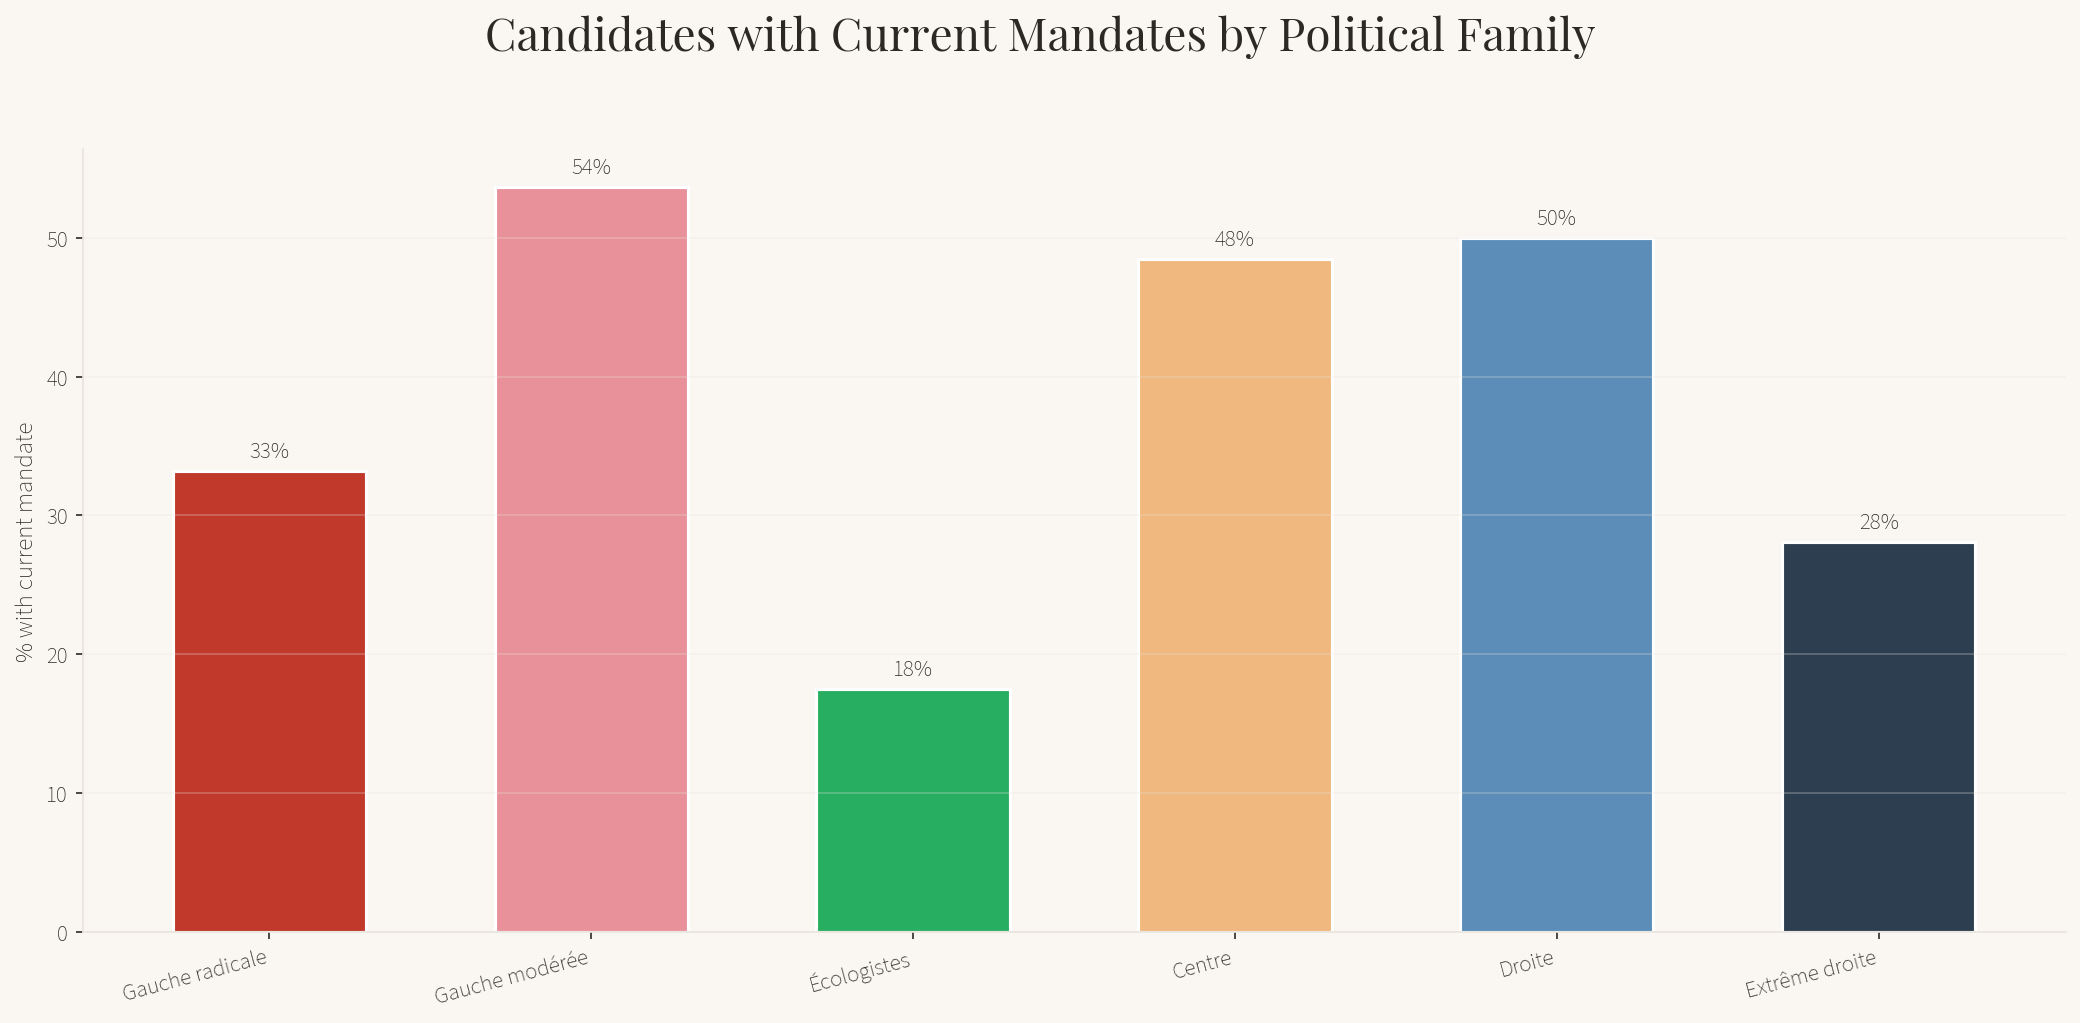

In [21]:
# Statistics table
df_mandats = df_party.copy()
df_mandats['has_mandat'] = df_mandats['titulaire-mandat-en-cours'].apply(
    lambda x: x if isinstance(x, str) and x.lower() != 'non mentionné' else None)
mandat_rate = df_mandats.groupby('famille_politique')['has_mandat'].apply(
    lambda x: x.notna().mean() * 100).reindex(FAMILIES).round(1)
print("=== Incumbency rate (%) by political family ===\n")
print(mandat_rate.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Candidates with Current Mandates by Political Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

colors = [FAMILY_COLORS.get(f, '#A89F96') for f in FAMILIES]
bars = ax.bar(range(len(FAMILIES)), mandat_rate.values, width=0.6,
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(FAMILIES)))
ax.set_xticklabels(FAMILIES, fontsize=11, rotation=15, ha='right')
ax.set_ylabel("% with current mandate", fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, mandat_rate.values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/mandats_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Incumbency.** The *droite* and *centre* show the highest rates of sitting officeholders among their candidates, reflecting the cumul des mandats tradition and the advantage of established governing parties. The *gauche radicale* and *extrême droite* have the lowest rates, consistent with their challenger status in most constituencies.

### 9.6 Text length distribution by political family

=== Text length statistics by political family ===

                     mean  median     std
famille_politique                        
Gauche radicale    5754.0  5824.0  2024.0
Gauche modérée     4133.0  3788.0  2023.0
Écologistes        3632.0  3238.0  2200.0
Centre             3752.0  3268.0  1926.0
Droite             3910.0  3387.0  2132.0
Extrême droite     5185.0  5209.0  2436.0


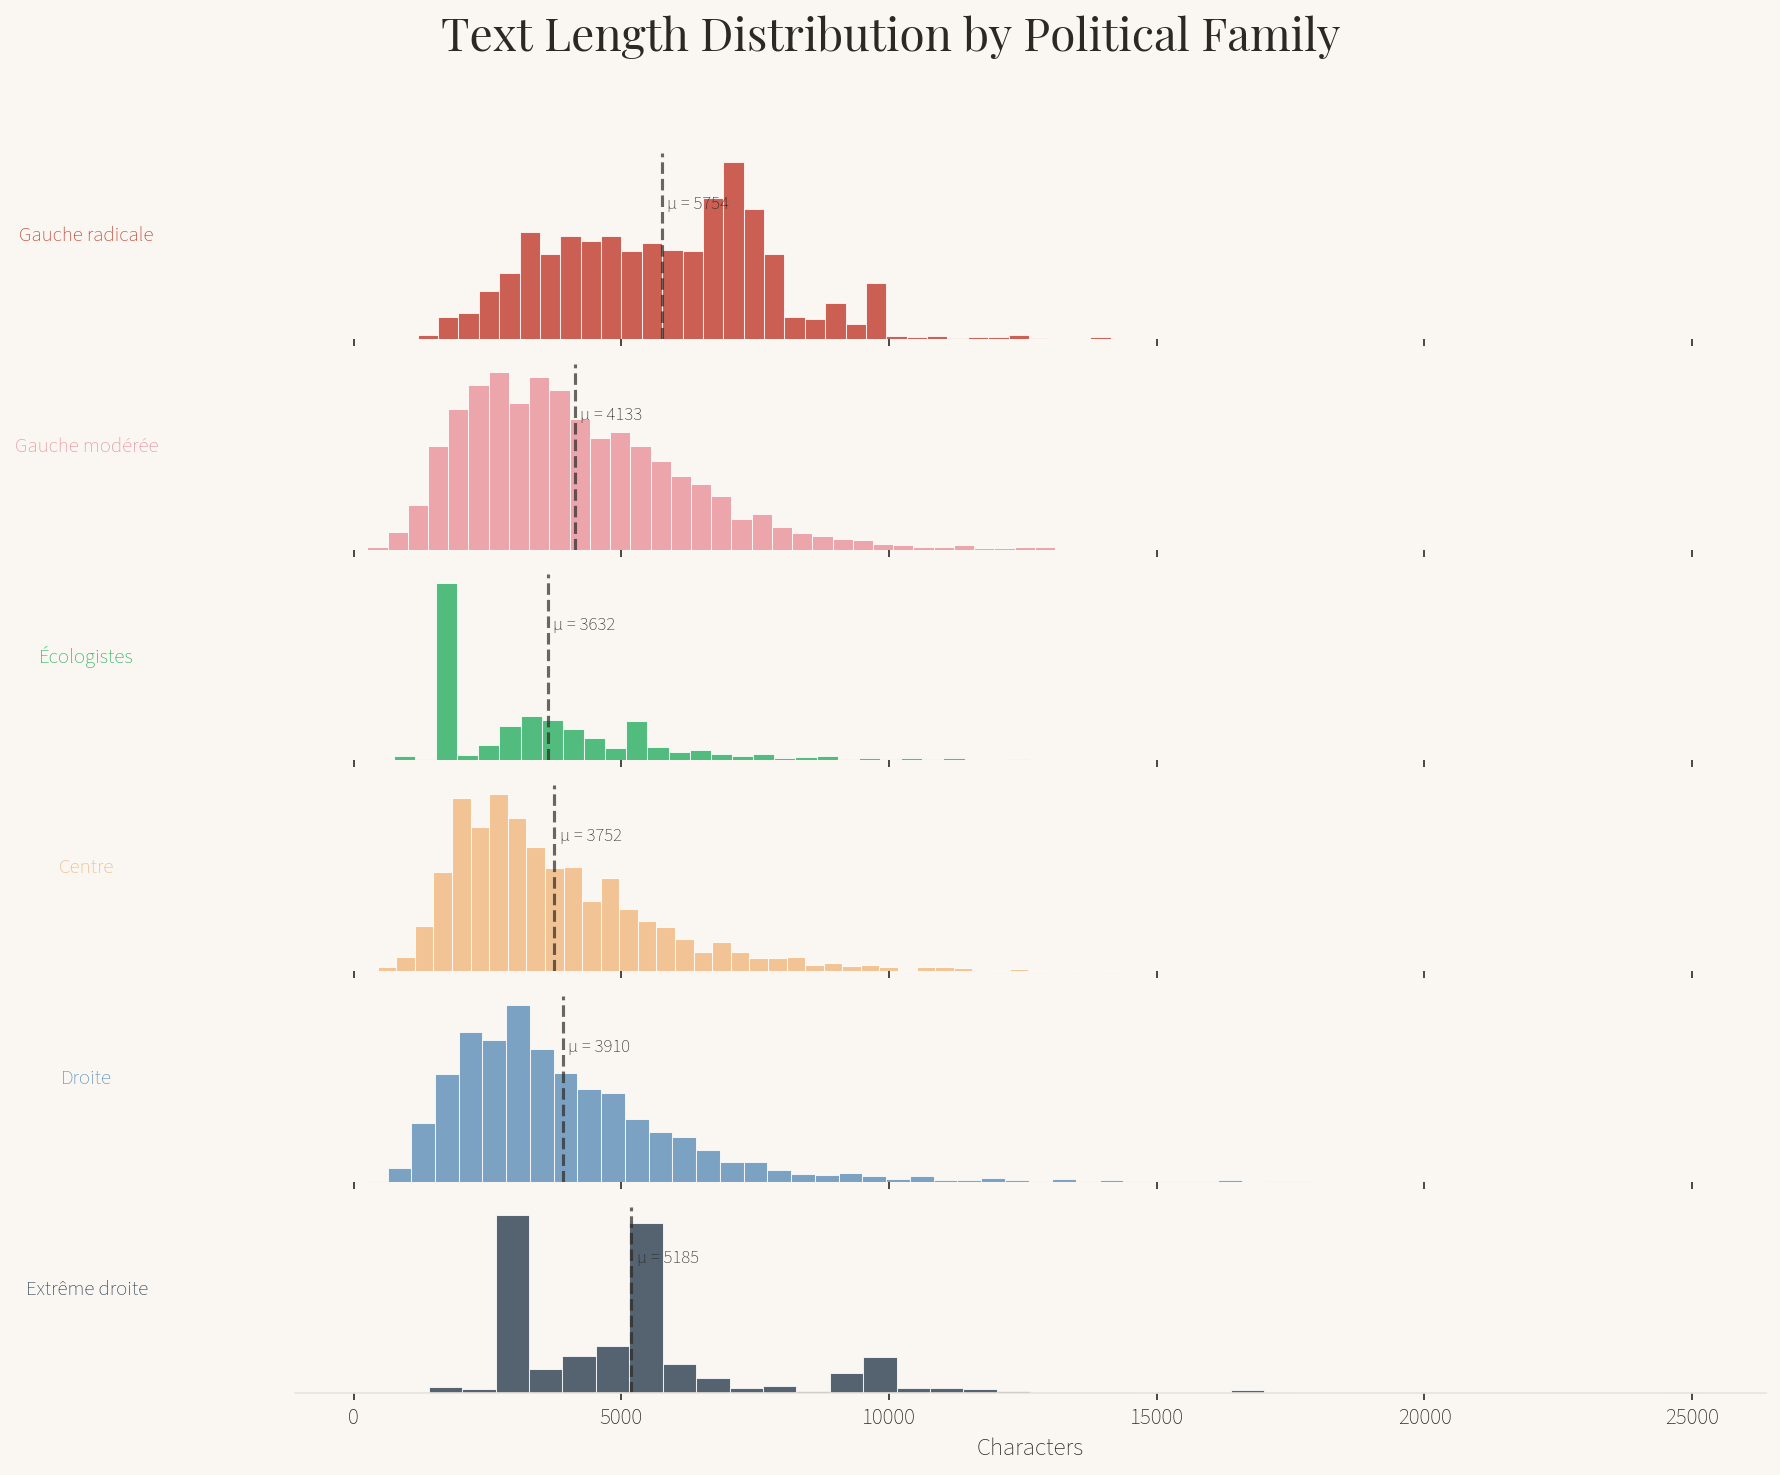

In [22]:
# Statistics table
length_stats = df_party.groupby('famille_politique')['text_length'].agg(['mean', 'median', 'std']).reindex(FAMILIES).round(0)
print("=== Text length statistics by political family ===\n")
print(length_stats.to_string())

# Plot
fig, axes = plt.subplots(len(FAMILIES), 1, figsize=(12, 10), sharex=True)
fig.suptitle("Text Length Distribution by Political Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for i, fam in enumerate(FAMILIES):
    ax = axes[i]
    data = df_party[df_party['famille_politique'] == fam]['text_length']
    color = FAMILY_COLORS.get(fam, '#A89F96')
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(), color=TEXT_COLOR, linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(data.mean() + 100, ax.get_ylim()[1] * 0.7,
            f'μ = {data.mean():.0f}', fontsize=9, color=TEXT_COLOR)
    ax.set_ylabel(fam, fontsize=10, fontfamily=FONT_BODY, fontweight='bold',
                  rotation=0, labelpad=100, color=color)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

axes[-1].set_xlabel("Characters", fontsize=12)
axes[-1].spines['bottom'].set_visible(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/longueur_par_parti.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Text length.** The physical format of the *profession de foi* (a standardized printed leaflet) constrains text length across all families. However, the *gauche radicale* tends to produce slightly longer manifestos, consistent with the didactic tradition of communist and Trotskyist campaign literature. The *extrême droite* and *écologistes* show more compact texts.

### 9.7 Candidacy trends over time

=== Number of candidacies by family and year ===

famille_politique  Gauche radicale  Gauche modérée  Écologistes  Centre  Droite  Extrême droite
year                                                                                           
1973                          1098             757            1     547     840             120
1978                          1500            1006           84     255     768             212
1981                           869             813           42     229     361              58
1988                           557             259           24     235     396             548
1993                           943             535         1199     551     694             652


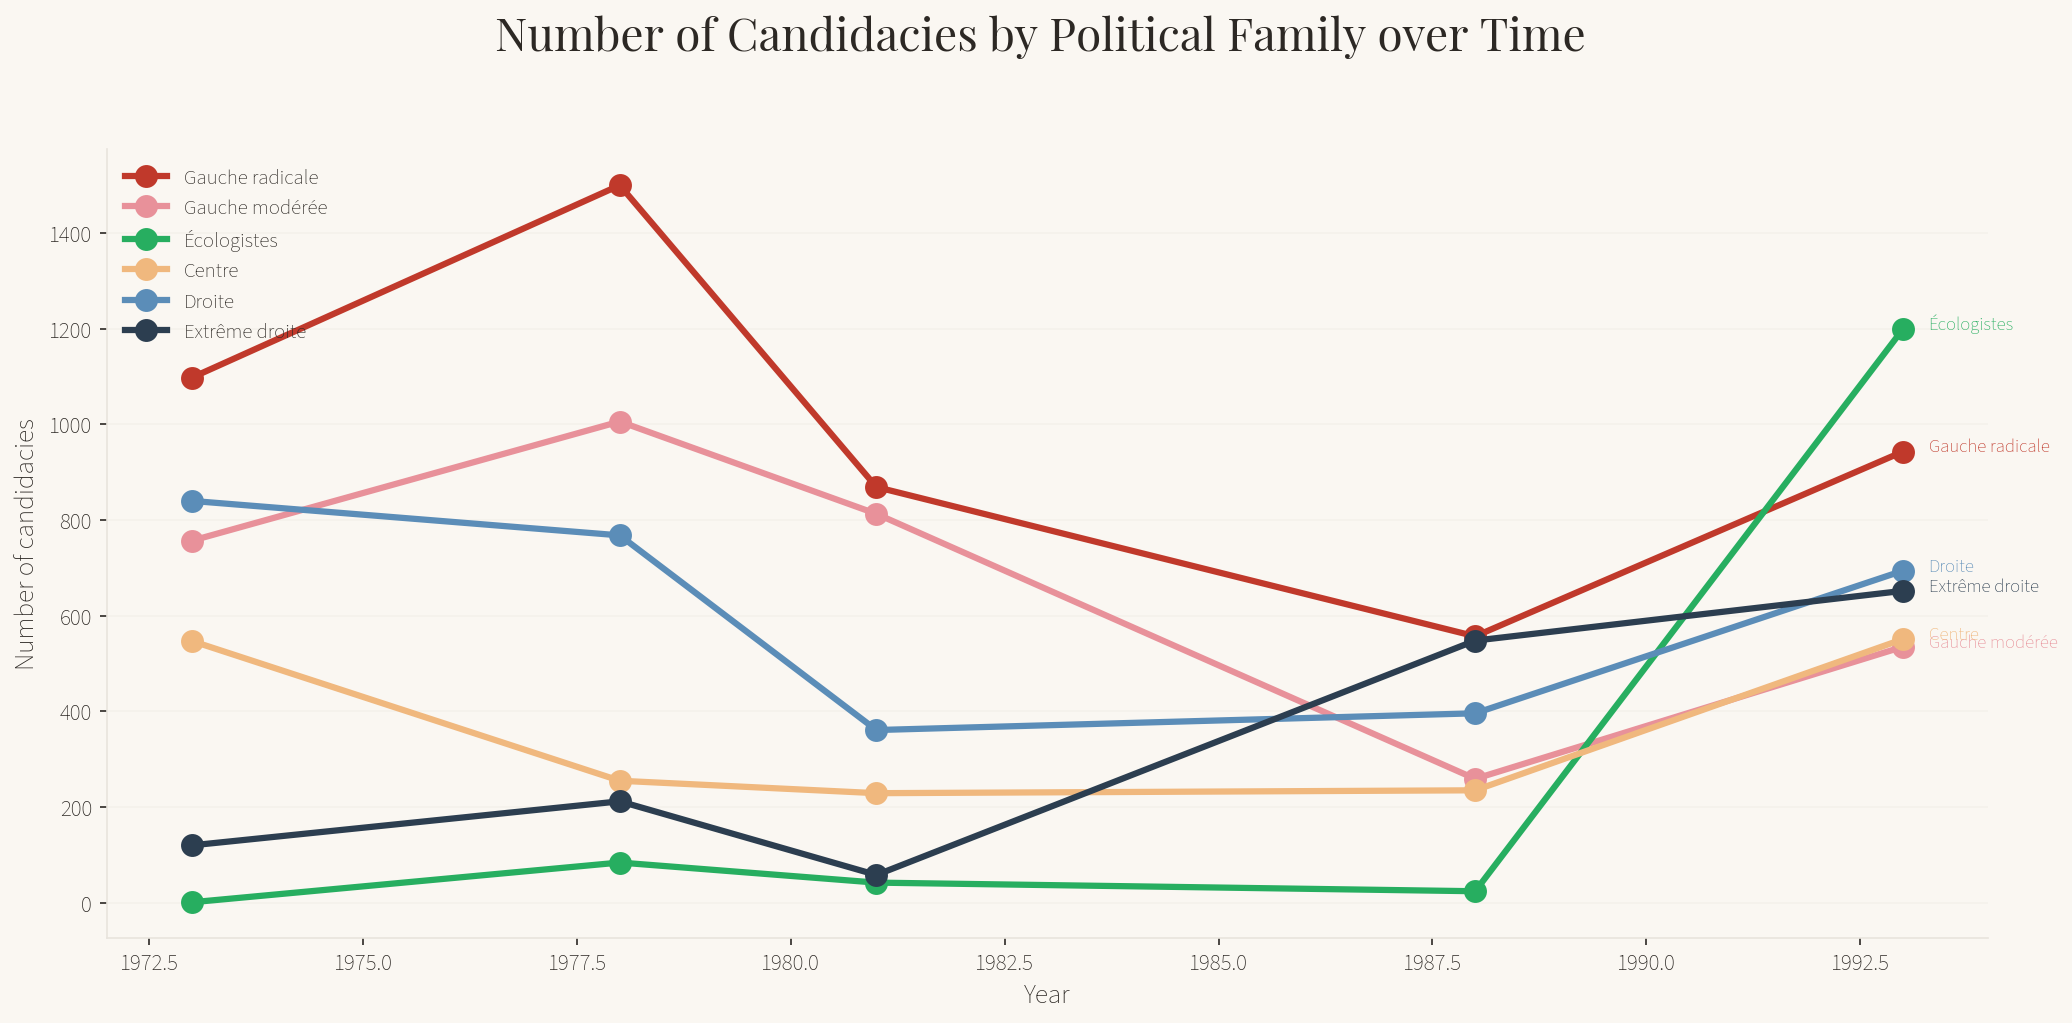

In [23]:
# Statistics table
cand_counts = df_party.groupby(['year', 'famille_politique']).size().unstack(fill_value=0)
cand_counts = cand_counts.reindex(columns=FAMILIES, fill_value=0)

cand_counts.index = cand_counts.index.astype(int)
# --------------------------------------------------------------------------

print("=== Number of candidacies by family and year ===\n")
print(cand_counts.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Number of Candidacies by Political Family over Time",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

for fam in FAMILIES:
    if fam not in cand_counts.columns:
        continue
    data = cand_counts[fam]
    ax.plot(data.index, data.values, marker='o', markersize=10,
            linewidth=3, label=fam, color=FAMILY_COLORS.get(fam, '#A89F96'))
    
    ax.text(data.index[-1] + 0.3, data.values[-1], fam,
            fontsize=9, color=FAMILY_COLORS.get(fam, TEXT_COLOR), fontweight='bold')

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of candidacies", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/evolution_candidatures.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 9.8 Decorated candidates by political family

=== Decoration rate (%) by political family ===

famille_politique
Gauche radicale     2.9
Gauche modérée      7.4
Écologistes         1.5
Centre             15.0
Droite             19.9
Extrême droite     16.7


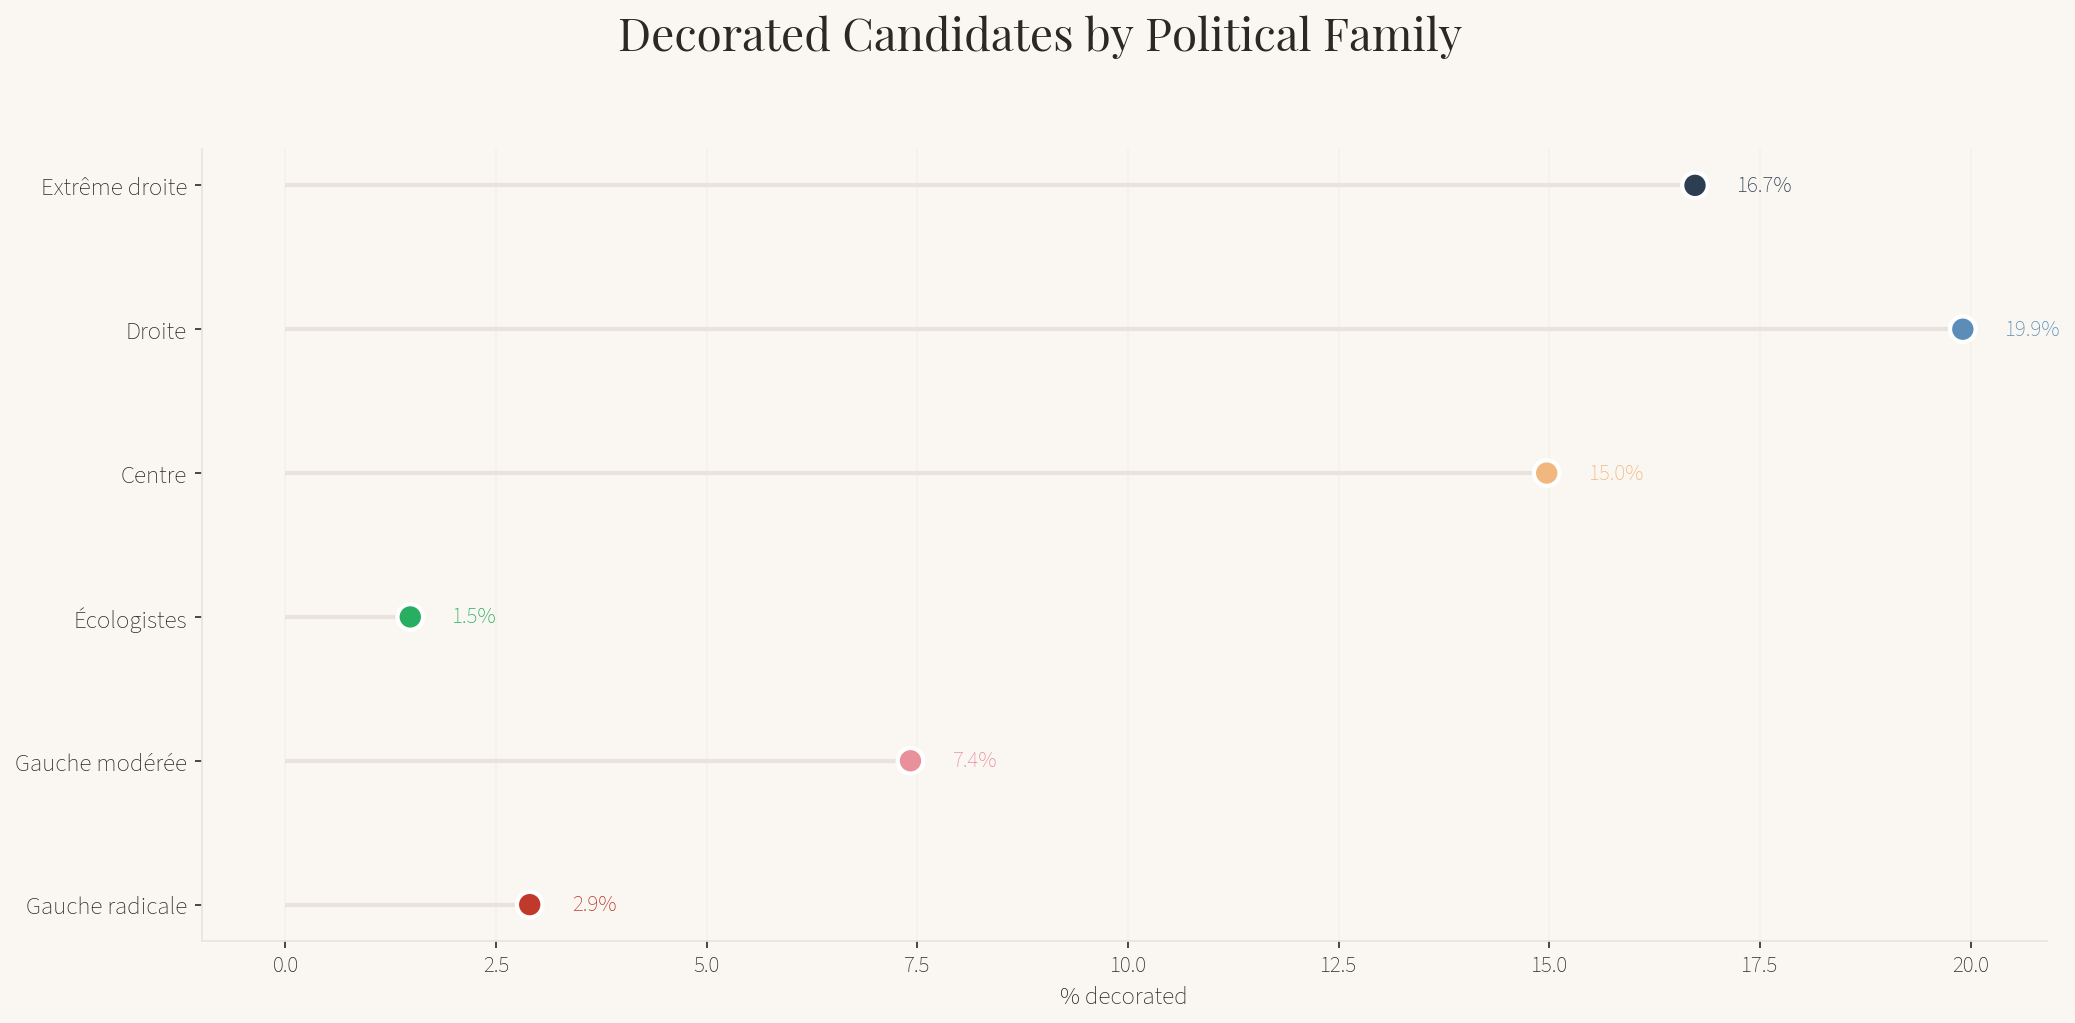

In [24]:
# Statistics table
df_deco = df_party.copy()
df_deco['est_decore'] = df_deco['titulaire-decorations'].apply(
    lambda x: True if isinstance(x, str) and x.lower() not in ['non', 'non mentionné', ''] else False)
deco_rate = df_deco.groupby('famille_politique')['est_decore'].mean().reindex(FAMILIES) * 100
print("=== Decoration rate (%) by political family ===\n")
print(deco_rate.round(1).to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Decorated Candidates by Political Family",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

colors = [FAMILY_COLORS.get(f, '#A89F96') for f in FAMILIES]
ax.hlines(range(len(FAMILIES)), 0, deco_rate.values, color=GRID_COLOR, linewidth=2)
ax.scatter(deco_rate.values, range(len(FAMILIES)), s=150, zorder=3,
           color=colors, edgecolors='white', linewidth=2)

for i, (fam, val) in enumerate(zip(FAMILIES, deco_rate.values)):
    if not np.isnan(val):
        ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=11,
                fontweight='bold', color=FAMILY_COLORS.get(fam, TEXT_COLOR))

ax.set_yticks(range(len(FAMILIES)))
ax.set_yticklabels(FAMILIES, fontsize=12, fontfamily=FONT_BODY)
ax.set_xlabel("% decorated", fontsize=12)
ax.spines['bottom'].set_visible(True)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/decorations_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Decorations.** The *droite* shows the highest decoration rate, consistent with its recruitment from military, senior civil service, and business elites where state honors (Légion d'honneur, Ordre national du Mérite) are common. The *gauche radicale* and *extrême droite* have the lowest rates, reflecting their anti-establishment positioning.

### 9.9 PCS evolution over time

=== Top 8 PCS categories (%) by year ===

profession_pcs  Enseignant, chercheur, universitaire  Profession juridique  Employé, fonctionnaire  Ouvrier  Cadre supérieur, ingénieur  Cadre moyen, technicien  Profession commerciale, vente  Agriculteur, exploitant agricole
year                                                                                                                                                                                                                             
1973                                            26.5                  17.7                    14.1     12.0                         9.9                      5.9                            4.2                               4.9
1978                                            19.9                  16.0                    17.8     20.2                         8.1                      5.8                            3.8                               3.7
1981                                            25.4  

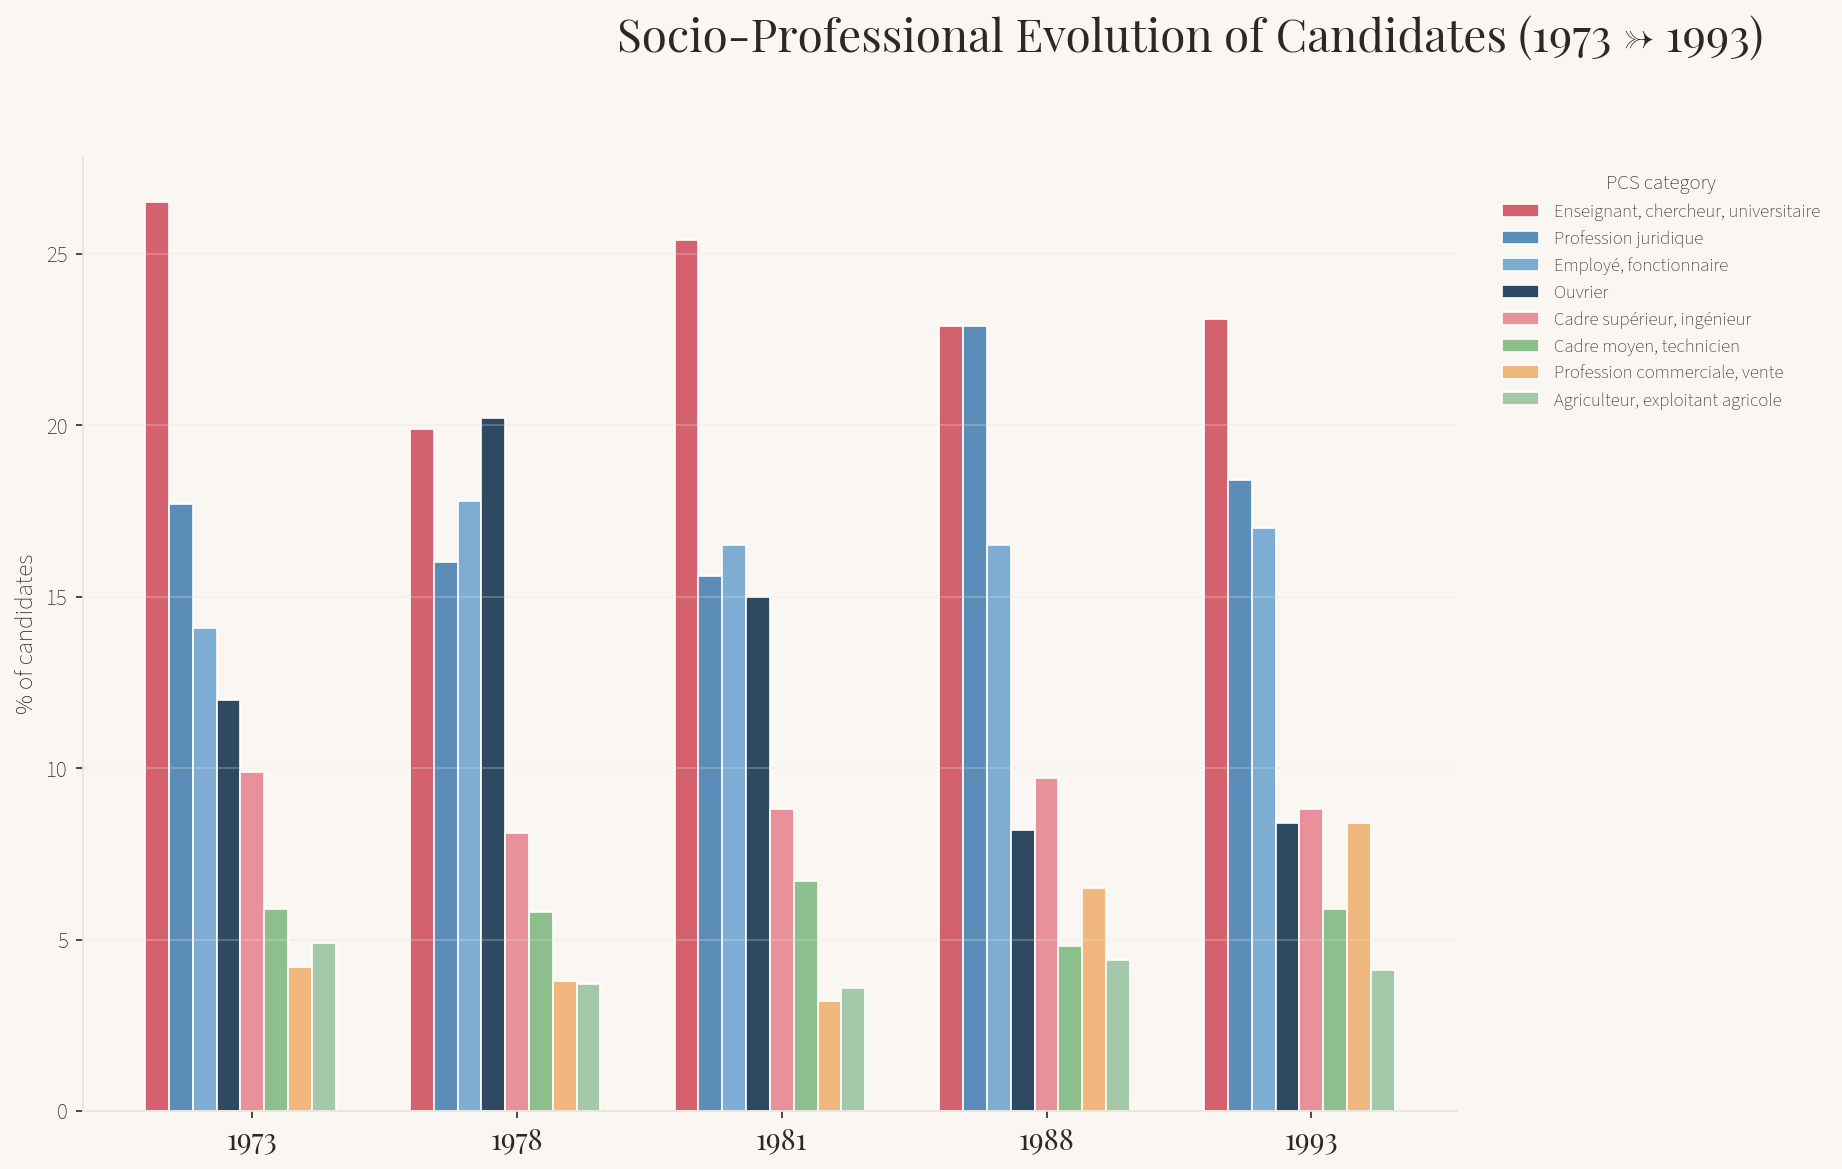

In [25]:
# Statistics table
df_pcs_year = df[df['profession_pcs'] != 'Non renseigné'].copy()
ct_pcs = pd.crosstab(df_pcs_year['year'], df_pcs_year['profession_pcs'], normalize='index') * 100
top_pcs = df_pcs_year['profession_pcs'].value_counts().head(8).index.tolist()
ct_pcs_top = ct_pcs[top_pcs].round(1)
print("=== Top 8 PCS categories (%) by year ===\n")
print(ct_pcs_top.to_string())

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle("Socio-Professional Evolution of Candidates (1973 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

x = np.arange(len(ct_pcs_top.index))
width = 0.09
n_cat = len(top_pcs)

for i, pcs in enumerate(top_pcs):
    offset = (i - n_cat/2) * width
    color = PCS_COLORS.get(pcs, '#A89F96')
    ax.bar(x + offset, ct_pcs_top[pcs], width=width, label=pcs,
           color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct_pcs_top.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% of candidates", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9,
          title="PCS category", title_fontproperties={'weight': 'bold', 'size': 10})

plt.tight_layout(rect=[0, 0, 0.78, 0.93])
plt.savefig("../data/pcs_evolution.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**PCS evolution.** The socio-professional composition of candidates shifts over the period. Teachers and legal professionals remain the dominant categories throughout, but the share of blue-collar workers declines, mirroring the broader deindustrialization of French society and the weakening of the PCF's working-class candidate pipeline.

---

## 10. Save Enriched Dataset

In [26]:
df.to_pickle("../data/df_explore.pkl")
print(f"Enriched DataFrame saved: {len(df):,} rows × {len(df.columns)} columns")
print(f"New columns: text_clean, tokens, n_tokens, famille_politique, profession_pcs")
print(f"\nFAMILIES list: {FAMILIES}")
print(f"Documents with family label: {df['famille_politique'].notna().sum():,}")
print(f"Documents excluded (non mentionné): {df['famille_politique'].isna().sum():,}")

Enriched DataFrame saved: 21,697 rows × 52 columns
New columns: text_clean, tokens, n_tokens, famille_politique, profession_pcs

FAMILIES list: ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']
Documents with family label: 17,127
Documents excluded (non mentionné): 4,570


---

## 11. Summary & Next Steps

### What we achieved

| Step | Result |
|------|--------|
| Text cleaning | Lowercased, stripped punctuation/digits, removed stopwords |
| Tokenization | ~350 tokens/document on average |
| Political family classification | 6 families (gauche radicale, gauche modérée, écologistes, centre, droite, extrême droite) from hundreds of raw labels |
| Non mentionné exclusion | ~18.6% of corpus excluded from party-based analyses |
| Profession mapping | 15 PCS categories via BERT zero-shot (cached) |
| Visualizations | Publication-quality figures with statistics tables and markdown interpretations |

### Key findings

- The **gauche radicale** dominates in number of candidacies but declines over time, while the **extrême droite** surges after 1981.
- **Teachers** are the most represented profession across the political spectrum, especially in the *gauche modérée*.
- **Blue-collar workers** are concentrated in the *gauche radicale*, while **executives and legal professionals** dominate the *droite* and *centre*.
- Female candidacies remain below 20% across all families throughout the period.

### What comes next

In **Notebook 03 (Topic Modeling)**, we will:
- Build document-term matrices using TF-IDF weighting. (Ref: Lecon 1 - Vector Representation for NLP)
- Train LDA and NMF models to extract latent themes, evaluating quality with C_v coherence. (Ref: Lecon 6 - Topic Modelling)
- Analyze thematic specialization by **political family** and temporal evolution of discourse